In [1]:
import os
import csv
from pathlib import Path

import yaml
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Set Random seed
import os
import random
import numpy as np
import torch
 
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)   # affects hash-based ordering (dict/set), only fully effective if set before interpreter starts
    random.seed(seed)                          # Python's built-in random
    np.random.seed(seed)                       # NumPy
    torch.manual_seed(seed)                    # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch current GPU
    torch.cuda.manual_seed_all(seed)            # PyTorch all GPUs
   

    # Extra determinism settings for PyTorch (optional but recommended)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 1. Config — edit these for your setup

In [3]:
# --- Option A: point at data.yaml + process all splits together --------
DATA_YAML =  r"D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\data.yaml"
DATASET_ROOT = r"D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4"

# Processed together and pooled into one feature table, so healthy images
# stratified across all three splits are all counted (not just train's share).
SPLITS_TO_PROCESS = ["train", "valid", "test"]

# --- Option B: point directly at one folder pair (overrides A if set) --
LABELS_DIR = None   # e.g. r"D:\...\basal_dataset_v4\train\labels"
IMAGES_DIR = None   # e.g. r"D:\...\basal_dataset_v4\train\images"

# Class names (only needed if you don't want to read them from data.yaml)
CLASS_NAMES = None  # e.g. ["mushroom", "rot", "white-button"]

OUT_CSV = "severity_pseudolabels_all_splits.csv"

# --- Feature weights (tune after validating against domain expert judgement) ---
ALPHA_ROT_AREA = 0.5          # weight on rot_area_ratio
BETA_FRUITING_BODY = 0.3      # weight on fruiting_body_count
GAMMA_ROT_INSTANCES = 0.2     # weight on rot_instance_count

# --- Rule thresholds on rot_area_ratio, mirroring MPOB stem-rot % bands ---
RULE_MODERATE_MIN = 0.10
RULE_SEVERE_MIN = 0.30
RULE_SEVERE_FRUITING_BODY_COUNT = 3  # multifocal fruiting bodies -> severe

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


## 2. Helper functions

In [4]:
import os
import yaml
from pathlib import Path


def load_class_names(data_yaml_path):
    with open(data_yaml_path, "r") as f:
        cfg = yaml.safe_load(f)

    names = cfg.get("names")

    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]

    return names


def resolve_split_dirs(data_yaml_path, split, dataset_root=None):
    """
    Resolve images/labels directories for a split.

    If the paths in the YAML file do not exist locally,
    the function tries to re-root them under dataset_root.
    This handles relative vs. absolute path mismatches.
    """

    with open(data_yaml_path, "r") as f:
        cfg = yaml.safe_load(f)

    split_key = {
        "train": "train",
        "val": "val",
        "valid": "val",
        "test": "test"
    }[split]

    images_path = cfg[split_key]

    images_dir = Path(images_path)

    # If YAML path is relative or does not exist,
    # try dataset_root
    if not images_dir.is_absolute() or not images_dir.exists():

        if dataset_root:

            folder_name = {
                "train": "train",
                "val": "valid",
                "test": "test"
            }[split_key]

            candidate = (
                Path(dataset_root)
                / folder_name
                / "images"
            )

            if candidate.exists():
                images_dir = candidate

    # Replace images -> labels
    labels_dir = Path(
        str(images_dir).replace(
            "images",
            "labels"
        )
    )

    return images_dir, labels_dir


def parse_label_file(label_path, class_names):
    """
    Parse one YOLO .txt annotation file.

    Returns feature counts and areas.

    An empty or missing label file naturally yields
    all-zero features, which represents an image
    with no detected symptoms.
    """

    fruiting_body_count = 0
    rot_instance_count = 0
    rot_area_ratio = 0.0
    box_count = 0

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) < 5:
                    continue

                cls_id = int(float(parts[0]))
                w = float(parts[3])
                h = float(parts[4])

                # YOLO width × height is already normalized
                # to image area
                area = w * h

                # Ignore invalid class IDs
                if cls_id < 0 or cls_id >= len(class_names):
                    continue

                cls_name = class_names[cls_id]

                box_count += 1

                if cls_name in (
                    "mushroom",
                    "white-button"
                ):
                    fruiting_body_count += 1

                elif cls_name == "rot":
                    rot_instance_count += 1
                    rot_area_ratio += area

    return {
        "box_count": box_count,
        "fruiting_body_count": fruiting_body_count,
        "rot_instance_count": rot_instance_count,
        "rot_area_ratio": rot_area_ratio,
    }


def rule_based_class(features):
    """
    Explicit rule anchored to MPOB stem-rot percentage bands.

    Healthy occurs naturally when both fruiting-body and
    rot counts are zero.
    """

    fb = features["fruiting_body_count"]
    rot_n = features["rot_instance_count"]
    area = features["rot_area_ratio"]

    # Healthy
    if fb == 0 and rot_n == 0:
        return "Healthy"

    # Severe
    if (
        area >= RULE_SEVERE_MIN
        or fb >= RULE_SEVERE_FRUITING_BODY_COUNT
    ):
        return "Severe"

    # Moderate
    if area >= RULE_MODERATE_MIN:
        return "Moderate"

    # Mild
    return "Mild"


def compute_severity_score(features, norm_stats):
    """
    Weighted composite score using dataset-wide
    min-max normalized features.
    """

    def norm(name):

        lo, hi = norm_stats[name]
        val = features[name]

        if hi - lo < 1e-9:
            return 0.0

        return (val - lo) / (hi - lo)

    area_n = norm("rot_area_ratio")
    fb_n = norm("fruiting_body_count")
    rot_n = norm("rot_instance_count")

    return (
        ALPHA_ROT_AREA * area_n
        + BETA_FRUITING_BODY * fb_n
        + GAMMA_ROT_INSTANCES * rot_n
    )


def quartile_class(scores):
    """
    Return a classify(score) function using the
    dataset's own quartiles.
    """

    sorted_scores = sorted(scores)

    n = len(sorted_scores)

    def pct(p):

        idx = min(
            n - 1,
            max(
                0,
                int(round(p * (n - 1)))
            )
        )

        return sorted_scores[idx]

    q1 = pct(0.25)
    q2 = pct(0.50)
    q3 = pct(0.75)

    def classify(score):

        if score <= q1:
            return "Healthy"

        elif score <= q2:
            return "Mild"

        elif score <= q3:
            return "Moderate"

        else:
            return "Severe"

    return classify, (q1, q2, q3)

## 3. Resolve paths and class names

In [5]:
class_names = CLASS_NAMES or load_class_names(DATA_YAML)

if LABELS_DIR:
    # Option B: a single explicit folder pair, bypasses split resolution
    labels_dir_b = Path(LABELS_DIR)
    images_dir_b = Path(IMAGES_DIR) if IMAGES_DIR else Path(str(labels_dir_b).replace("labels", "images"))
    split_dirs = [("custom", images_dir_b, labels_dir_b)]
else:
    split_dirs = []
    for split in SPLITS_TO_PROCESS:
        images_dir, labels_dir = resolve_split_dirs(DATA_YAML, split, DATASET_ROOT)
        split_dirs.append((split, images_dir, labels_dir))

for split_name, images_dir, labels_dir in split_dirs:
    status = "OK" if labels_dir.exists() else "MISSING"
    print(f"[{split_name:6s}] images: {images_dir}  |  labels: {labels_dir}  ({status})")

assert any(labels_dir.exists() for _, _, labels_dir in split_dirs), \
    "None of the split label folders were found -- check DATA_YAML / DATASET_ROOT."
print("\nClass names:", class_names)


[train ] images: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\train\images  |  labels: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\train\labels  (OK)
[valid ] images: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\valid\images  |  labels: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\valid\labels  (OK)
[test  ] images: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\test\images  |  labels: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\test\labels  (OK)

Class names: ['mushroom', 'rot', 'white-button']


## 4. Build the list of images (includes healthy images with zero annotations)

In [6]:
records = []  # each: {"image": stem, "label_path": Path, "source": split name}

for split_name, images_dir, labels_dir in split_dirs:
    if not labels_dir.exists():
        print(f"Skipping split '{split_name}' -- labels dir not found: {labels_dir}")
        continue

    if images_dir.exists():
        image_files = sorted(p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS)
        for p in image_files:
            records.append({
                "image": f"{split_name}/{p.stem}",
                "label_path": labels_dir / f"{p.stem}.txt",
                "source": split_name,
            })
    else:
        # no images folder found -- fall back to whatever label files exist
        for lp in sorted(labels_dir.glob("*.txt")):
            records.append({"image": f"{split_name}/{lp.stem}", "label_path": lp, "source": split_name})

assert records, "No images/labels found to process."

from collections import Counter
split_counts = Counter(r["source"] for r in records)
print(f"Found {len(records)} images total across splits: {dict(split_counts)}")


Found 1292 images total across splits: {'train': 903, 'valid': 256, 'test': 133}


## 5. Extract features, compute severity_score, assign classes

In [7]:
rows = []
for rec in records:
    feats = parse_label_file(rec["label_path"], class_names)
    feats["image"] = rec["image"]
    feats["source"] = rec["source"]
    rows.append(feats)

# dataset-wide min/max for normalization
norm_stats = {}
for key in ("rot_area_ratio", "fruiting_body_count", "rot_instance_count"):
    vals = [r[key] for r in rows]
    norm_stats[key] = (min(vals), max(vals))

scores = []
for r in rows:
    r["severity_score"] = compute_severity_score(r, norm_stats)
    r["severity_class_rule"] = rule_based_class(r)
    scores.append(r["severity_score"])

lo, hi = min(scores), max(scores)
for r in rows:
    r["severity_score_norm"] = 0.0 if hi - lo < 1e-9 else (r["severity_score"] - lo) / (hi - lo)

classify_fn, (q1, q2, q3) = quartile_class(scores)
for r in rows:
    r["severity_class_quartile"] = classify_fn(r["severity_score"])

print(f"Quartile cut points: Q1={q1:.4f}  Q2={q2:.4f}  Q3={q3:.4f}")

# sanity check: how many Healthy (rule-based) images came from each split
from collections import Counter
healthy_by_split = Counter(r["source"] for r in rows if r["severity_class_rule"] == "Healthy")
print("Healthy images by split:", dict(healthy_by_split), "  Total:", sum(healthy_by_split.values()))


Quartile cut points: Q1=0.0250  Q2=0.0375  Q3=0.0750
Healthy images by split: {'train': 55, 'valid': 15, 'test': 9}   Total: 79


## 6. View as DataFrame

In [8]:
import pandas as pd
df = pd.DataFrame(rows)
cols = ["image", "source", "box_count", "fruiting_body_count", "rot_instance_count",
        "rot_area_ratio", "severity_score", "severity_score_norm",
        "severity_class_rule", "severity_class_quartile"]
df = df[cols]
df.head(10)


,image,source,box_count,fruiting_body_count,rot_instance_count,rot_area_ratio,severity_score,severity_score_norm,severity_class_rule,severity_class_quartile
0,train/IMG_0001_JPG.rf.be0654b91c218a77ffd803a8...,train,1,0,1,0.090033,0.031086,0.040769,Mild,Mild
1,train/IMG_0002_JPG.rf.627925f0c6ef1291d68522b9...,train,1,0,1,0.393949,0.068510,0.089849,Severe,Moderate
2,train/IMG_0002_JPG.rf.bde94967a70755c35da22e28...,train,1,0,1,0.082018,0.030100,0.039475,Mild,Mild
3,train/IMG_0003_JPG.rf.cf92fa53bbb07481bd6cea47...,train,1,0,1,0.321426,0.059580,0.078137,Severe,Moderate
4,train/IMG_0005_JPG.rf.46785a6743ede521eb92468a...,train,2,0,2,0.605532,0.114564,0.150248,Severe,Severe
5,train/IMG_0005_JPG.rf.53118a7726d6bad1f5a823df...,train,2,0,2,0.505521,0.102249,0.134097,Severe,Severe
6,train/IMG_0006_JPG.rf.a2c4e47c01c8f8f458ef01bd...,train,1,1,0,0.000000,0.012500,0.016393,Mild,Healthy
7,train/IMG_0006_JPG.rf.eb81bcf02b7fa723d6598cb1...,train,1,1,0,0.000000,0.012500,0.016393,Mild,Healthy
8,train/IMG_0007_JPG.rf.1aacce00c5f52b64d03b8b59...,train,1,1,0,0.000000,0.012500,0.016393,Mild,Healthy
9,train/IMG_0008_JPG.rf.ee1887c99debed81cde6e30c...,train,6,2,4,1.383355,0.275343,0.361105,Severe,Severe


## 7. Class distribution (rule vs. quartile) — cross-check

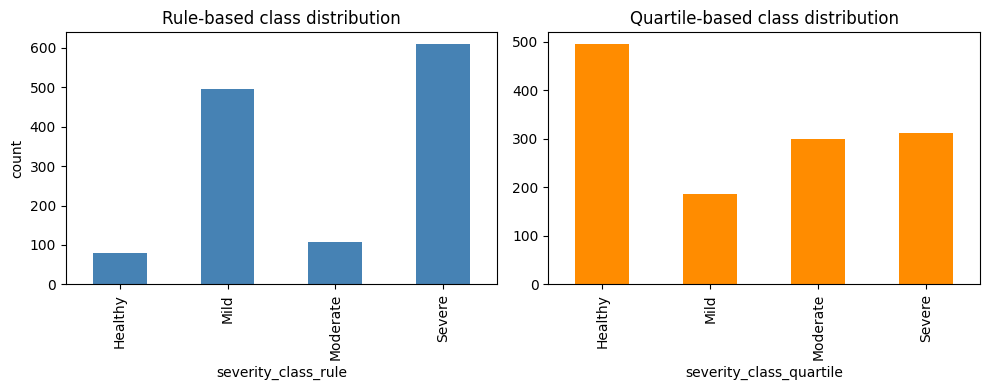

Agreement between the two labeling methods: 37.8%


In [9]:
order = ["Healthy", "Mild", "Moderate", "Severe"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["severity_class_rule"].value_counts().reindex(order).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rule-based class distribution")
axes[0].set_ylabel("count")

df["severity_class_quartile"].value_counts().reindex(order).plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Quartile-based class distribution")

plt.tight_layout()
plt.show()

print("Agreement between the two labeling methods:",
      f"{(df['severity_class_rule'] == df['severity_class_quartile']).mean():.1%}")

## 8. Sanity check: confirm healthy images 

Since healthy images are no longer force-labeled, this plot is your evidence that they
genuinely have near-zero `rot_area_ratio` and box counts — worth including in the paper
as validation that the rule correctly separates them from symptomatic images.

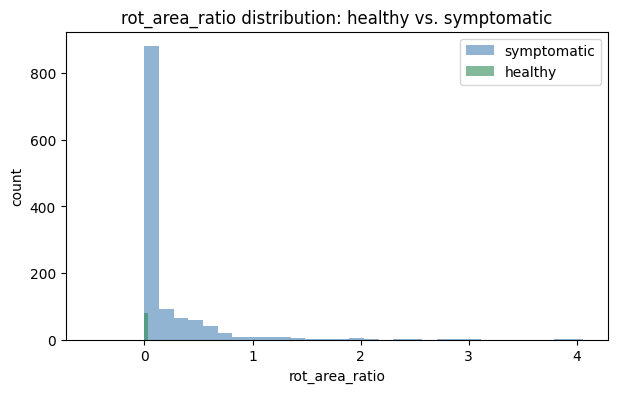

Healthy images: 79 / 1292 (6.1%)
severity_class_rule        healthy  symptomatic
rot_area_ratio      count     79.0  1213.000000
                    mean       0.0     0.165227
                    std        0.0     0.383499
                    min        0.0     0.000000
                    25%        0.0     0.000000
                    50%        0.0     0.000000
                    75%        0.0     0.178763
                    max        0.0     4.060501
fruiting_body_count count     79.0  1213.000000
                    mean       0.0     2.670239
                    std        0.0     3.200930
                    min        0.0     0.000000
                    25%        0.0     1.000000
                    50%        0.0     2.000000
                    75%        0.0     3.000000
                    max        0.0    24.000000
rot_instance_count  count     79.0  1213.000000
                    mean       0.0     0.671888
                    std        0.0     1.092810
       

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
healthy_mask = df["severity_class_rule"] == "Healthy"
ax.hist(df.loc[~healthy_mask, "rot_area_ratio"], bins=30, alpha=0.6, label="symptomatic", color="steelblue")
ax.hist(df.loc[healthy_mask, "rot_area_ratio"], bins=30, alpha=0.6, label="healthy", color="seagreen")
ax.set_xlabel("rot_area_ratio")
ax.set_ylabel("count")
ax.set_title("rot_area_ratio distribution: healthy vs. symptomatic")
ax.legend()
plt.show()

print(f"Healthy images: {healthy_mask.sum()} / {len(df)} ({healthy_mask.mean():.1%})")
print(df.groupby(healthy_mask.map({True: "healthy", False: "symptomatic"}))
        [["rot_area_ratio", "fruiting_body_count", "rot_instance_count"]].describe().T)

## 9. Save CSV

In [11]:
df.to_csv(OUT_CSV, index=False)
print(f"Saved: {Path(OUT_CSV).resolve()}")

Saved: C:\Users\User\my-notebooks\severity_pseudolabels_all_splits.csv


## 10. Train ML classifiers on: KNN  and Random Forest

Using `df` (now includes real healthy images naturally) with `severity_class_rule`
as the target.

**Feature note / caveat:** `rot_area_ratio` and `fruiting_body_count` are the
*exact* features the rule used to assign labels (`rot_area_ratio >= 0.30` etc).
Training a classifier on them isn't really testing whether severity is
"learnable" from independent evidence — it's closer to checking whether the
model can re-derive the same thresholds. That's still a useful sanity check
(if KNN/Random Forest can't hit ~95%+ accuracy on features that literally define
the label, something's wrong in the data/split). But when you eventually
get real DSI ground truth, re-run this against that instead for a genuine
evaluation.

Install packages if you don't already have them:
```
pip install scikit-learn --break-system-packages
```
(drop `--break-system-packages` if you're in a normal venv/conda env)

In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

FEATURE_COLS = ["box_count", "fruiting_body_count", "rot_instance_count", "rot_area_ratio"]
TARGET_COL = "severity_class_rule"   # change to "severity_class_quartile" to compare

model_df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

X = model_df[FEATURE_COLS].values
y_raw = model_df[TARGET_COL].values

CLASS_ORDER = ["Healthy", "Mild", "Moderate", "Severe"]
le = LabelEncoder()
le.fit(CLASS_ORDER)
y = le.transform(y_raw)

print("Feature matrix:", X.shape)
print("Class counts:\n", model_df[TARGET_COL].value_counts().reindex(CLASS_ORDER))


Feature matrix: (1292, 4)
Class counts:
 severity_class_rule
Healthy      79
Mild        496
Moderate    108
Severe      609
Name: count, dtype: int64


## 11. Train/test split — by dataset folder, matching how YOLO was trained

The YOLO models in this project are trained with `train/images` for fitting and
`valid/images` for monitoring, with `test/images` held out entirely and never seen
during training. To evaluate KNN/Random Forest the same way (rather than a random
80/20 shuffle that could leak train-folder images into the "test" set), this split
uses the actual `source` column: **fit on `train` + `valid`, evaluate only on `test`**.
That gives a genuine held-out check, not an inflated score from evaluating on data
the model effectively already "saw" via a sibling image from the same folder/session.


In [13]:
train_mask = model_df["source"].isin(["train", "valid"]).values
test_mask = (model_df["source"] == "test").values

assert train_mask.sum() > 0, "No rows found for source in ('train','valid') -- check SPLITS_TO_PROCESS / the 'source' column."
assert test_mask.sum() > 0, "No rows found for source == 'test' -- check that SPLITS_TO_PROCESS includes 'test' and that split has label files."

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train (train+valid folders):", X_train.shape[0], " Test (test folder, held out):", X_test.shape[0])
print("Train class distribution:", np.bincount(y_train, minlength=len(CLASS_ORDER)))
print("Test class distribution: ", np.bincount(y_test, minlength=len(CLASS_ORDER)))


Train (train+valid folders): 1159  Test (test folder, held out): 133
Train class distribution: [ 70 445  93 551]
Test class distribution:  [ 9 51 15 58]


## 12. KNN classifier 

KNN is distance-based, so features need to be scaled first (otherwise
`rot_area_ratio`, which ranges 0–1, gets swamped by `box_count`/`fruiting_body_count`,
which can be small integers but on a different scale).

In [14]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}

# StratifiedKFold keeps class proportions consistent across folds — important
# given the Moderate/Severe imbalance already noted in this notebook
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring="f1_macro",     # optimize for macro F1, not raw accuracy, given the imbalance
    cv=cv_strategy,
    n_jobs=-1,
)
knn_grid.fit(X_train_scaled, y_train)

print("=== KNN GridSearchCV ===")
print("Best params:", knn_grid.best_params_)
print(f"Best CV macro-F1: {knn_grid.best_score_:.3f}")

knn = knn_grid.best_estimator_
y_pred_knn = knn.predict(X_test_scaled)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred_knn, average='macro'):.3f}")
print(f"Test Weighted F1: {f1_score(y_test, y_pred_knn, average='weighted'):.3f}\n")
print(classification_report(y_test, y_pred_knn, target_names=CLASS_ORDER, zero_division=0))

=== KNN GridSearchCV ===
Best params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best CV macro-F1: 0.990

Test Accuracy: 0.992
Test Macro F1: 0.990
Test Weighted F1: 0.993

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         9
        Mild       1.00      1.00      1.00        51
    Moderate       0.94      1.00      0.97        15
      Severe       1.00      0.98      0.99        58

    accuracy                           0.99       133
   macro avg       0.98      1.00      0.99       133
weighted avg       0.99      0.99      0.99       133



## 13. Random Forest classifier

In [15]:
rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)   # no scaling needed for tree-based models

print("=== Random Forest GridSearchCV ===")
print("Best params:", rf_grid.best_params_)
print(f"Best CV macro-F1: {rf_grid.best_score_:.3f}")

rf_clf = rf_grid.best_estimator_
y_pred_rf = rf_clf.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print(f"Test Weighted F1: {f1_score(y_test, y_pred_rf, average='weighted'):.3f}\n")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_ORDER, zero_division=0))

=== Random Forest GridSearchCV ===
Best params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV macro-F1: 0.998

Test Accuracy: 1.000
Test Macro F1: 1.000
Test Weighted F1: 1.000

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         9
        Mild       1.00      1.00      1.00        51
    Moderate       1.00      1.00      1.00        15
      Severe       1.00      1.00      1.00        58

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133



## 14. Confusion matrices — side by side

Watch the **Moderate** row/column especially — with the smallest class,
it's the one most likely to get absorbed into its neighbors (Mild or Severe).

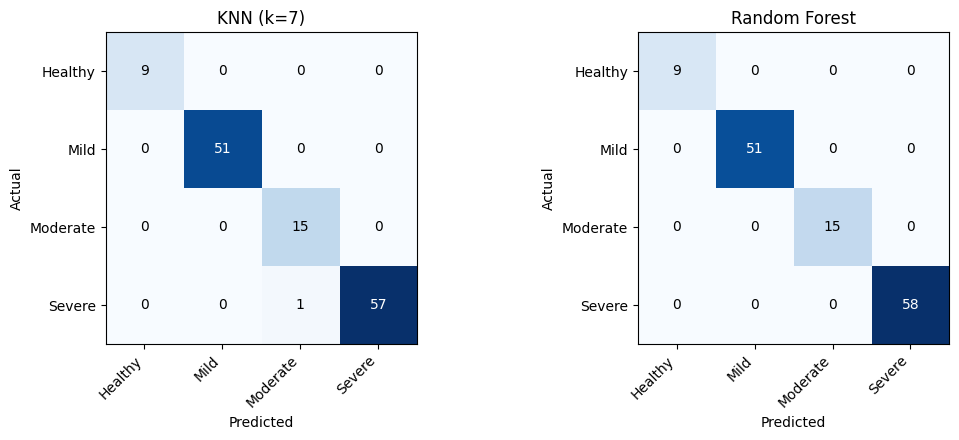

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, y_pred, title in [
    (axes[0], y_pred_knn, "KNN (k=7)"),
    (axes[1], y_pred_rf, "Random Forest"),
]:
    cm = confusion_matrix(y_test, y_pred, labels=range(len(CLASS_ORDER)))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 15. Feature importance (Random Forest) — which features drive the predictions

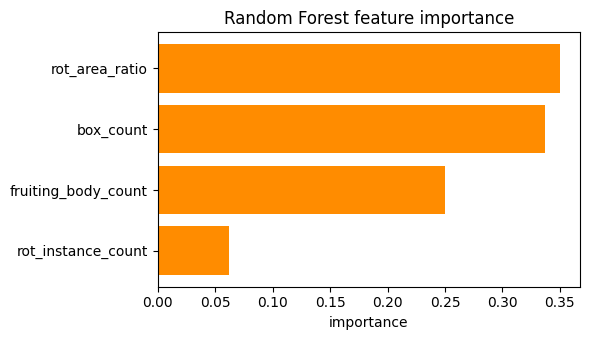

,feature,importance
3,rot_area_ratio,0.350048
0,box_count,0.337363
1,fruiting_body_count,0.250400
2,rot_instance_count,0.062189


In [17]:
importances = rf_clf.feature_importances_
imp_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": importances}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(imp_df["feature"], imp_df["importance"], color="darkorange")
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.show()

imp_df

## 16. Side-by-side summary + notes on the imbalance

If Moderate's recall is noticeably worse than the other classes in the
reports above, that's the imbalance showing up in practice, not a bug.
Two standard options if you want to address it later (not applied here
since you asked to keep the label distribution as-is):

- **`class_weight="balanced"`** — already stubbed in as a parameter in
  the Random Forest code cell above (currently set to `None`); switching
  it on penalizes misclassifying the minority class more heavily during training.
- **Oversampling** the minority class in the *training* set only (e.g.
  SMOTE) — never oversample before the train/test split, or you'll leak
  synthetic near-duplicates into the test set and inflate your reported
  accuracy.

In [18]:
summary = pd.DataFrame({
    "model": ["KNN (k=7)", "Random Forest"],
    "accuracy": [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)],
    "macro_f1": [f1_score(y_test, y_pred_knn, average="macro"), f1_score(y_test, y_pred_rf, average="macro")],
    "weighted_f1": [f1_score(y_test, y_pred_knn, average="weighted"), f1_score(y_test, y_pred_rf, average="weighted")],
})
summary

,model,accuracy,macro_f1,weighted_f1
0,KNN (k=7),0.992481,0.989762,0.99257
1,Random Forest,1.000000,1.000000,1.00000


## 17. (Optional) Isolate a single split

All splits are now pooled together above by default (`SPLITS_TO_PROCESS`). If you
ever want the pseudo-labels for just one split on its own, set
`SPLITS_TO_PROCESS = ["train"]` (or `"valid"` / `"test"`) in the Config cell,
give it its own `OUT_CSV` name, and re-run cells 3–13.

## 18. Explainability: SHAP analysis for KNN and Random Forest

SHAP (SHapley Additive exPlanations) values quantify how much each feature pushed a
prediction toward or away from each class, on average, giving a model-agnostic view of
which features drive the classifications rather than just how accurate they are.

- Random Forest uses `shap.TreeExplainer`, which computes exact SHAP values efficiently
  for tree ensembles.
- KNN has no tree structure to exploit, so we use the model-agnostic
  `shap.KernelExplainer` instead. It is far slower (it perturbs inputs and re-queries
  the model many times), so it's applied to a small background sample and a limited
  subset of test points (`N_KNN_SAMPLES`) rather than the full test set — sufficient to
  see the general pattern without a long runtime.

Install if needed: `pip install shap --break-system-packages`

Random Forest -- SHAP summary (mean |impact| per feature, per class)


C:\Users\User\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Temp\ipykernel_22220\92203291.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_shap_list, X_test, feature_names=FEATURE_COLS,


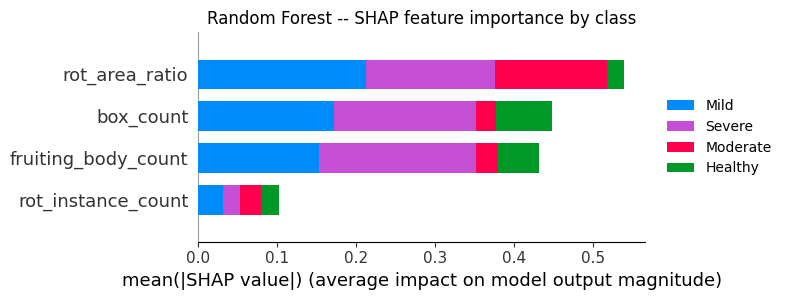

100%|█████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 212.83it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_22220\92203291.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(knn_shap_list, X_test_shap_subset, feature_names=FEATURE_COLS,



KNN (k=7) -- SHAP summary (first 40 test samples)


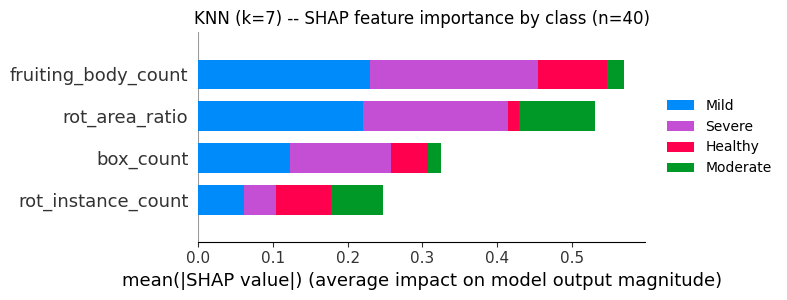

In [19]:
import shap

N_KNN_SAMPLES = 40  # KernelExplainer is slow -- explain only this many test points for KNN

# ---------------- Random Forest: exact TreeExplainer ----------------
rf_explainer = shap.TreeExplainer(rf_clf)
rf_shap = rf_explainer.shap_values(X_test)              # shape: (n_samples, n_features, n_classes)
rf_shap_list = [rf_shap[:, :, c] for c in range(len(CLASS_ORDER))]

print("Random Forest -- SHAP summary (mean |impact| per feature, per class)")
shap.summary_plot(rf_shap_list, X_test, feature_names=FEATURE_COLS,
                   class_names=CLASS_ORDER, plot_type="bar", show=False)
ax = plt.gca()
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.title("Random Forest -- SHAP feature importance by class")
plt.tight_layout()
plt.show()

# ---------------- KNN: model-agnostic KernelExplainer ----------------
knn_background = shap.sample(X_train_scaled, min(50, len(X_train_scaled)))
knn_explainer = shap.KernelExplainer(knn.predict_proba, knn_background)

X_test_shap_subset = X_test_scaled[:N_KNN_SAMPLES]
knn_shap = knn_explainer.shap_values(X_test_shap_subset, nsamples=100)  # shape: (n_samples, n_features, n_classes)
knn_shap_list = [knn_shap[:, :, c] for c in range(len(CLASS_ORDER))]

print(f"\nKNN (k=7) -- SHAP summary (first {N_KNN_SAMPLES} test samples)")
shap.summary_plot(knn_shap_list, X_test_shap_subset, feature_names=FEATURE_COLS,
                   class_names=CLASS_ORDER, plot_type="bar", show=False)
ax = plt.gca()
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.title(f"KNN (k=7) -- SHAP feature importance by class (n={N_KNN_SAMPLES})")
plt.tight_layout()
plt.show()

## 19. Real inference-time pipeline: YOLO predictions → features → severity

Everything above trains and evaluates KNN/Random Forest on features taken from
**ground-truth annotation boxes** — useful as a sanity check, but not what happens
in production. At inference time there are no hand-drawn boxes; there's only
whatever a trained YOLO model detects.

This section closes that gap: load a trained YOLO checkpoint (from
`BSR_siuhong_YOLO_v2.ipynb`), run it on the `test`-split images (the same images
those YOLO models never trained on), extract the identical four features from its
**predicted** boxes, and then:

1. Compare the rule-based class from YOLO's own detections against the ground-truth
   rule-based class — this isolates how much error the *detector* introduces on its own.
2. Feed those same predicted features into the KNN/Random Forest models already
   trained above (on train+valid ground truth) and compare their predictions against
   ground truth — this is the full, realistic end-to-end pipeline accuracy.

Expect this to score meaningfully lower than the ~95%+ seen earlier — that's expected
and informative, not a bug. The earlier number tested whether the classifier could
re-derive its own label rule; this one tests the whole system, detector included.


In [24]:
from ultralytics import YOLO
from pathlib import Path

# Point this at a trained checkpoint from BSR_siuhong_YOLO_v2.ipynb
# (run_name options there: "compare_yolov8n_v2", "compare_yolo11n_v2", "compare_yolo26n_v2")
YOLO_RUN_NAME = "compare_yolo26n_v2_seed2"
YOLO_WEIGHTS_PATH = os.path.join(DATASET_ROOT, "runs", "detect", YOLO_RUN_NAME, "weights", "best.pt")
YOLO_CONF_THRESHOLD = 0.25   # detection confidence threshold
YOLO_IMGSZ = 960             # match the imgsz used during training for consistent results

assert os.path.isfile(YOLO_WEIGHTS_PATH), \
    f"Checkpoint not found: {YOLO_WEIGHTS_PATH} -- update YOLO_RUN_NAME to a run you've actually trained"

yolo_model = YOLO(YOLO_WEIGHTS_PATH)
print("Loaded YOLO checkpoint:", YOLO_WEIGHTS_PATH)


Loaded YOLO checkpoint: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\runs\detect\compare_yolo26n_v2_seed2\weights\best.pt


In [25]:
def extract_features_from_yolo_result(result, class_names):
    """Same feature definitions as parse_label_file(), but computed from a YOLO
    prediction's boxes instead of a ground-truth .txt label file."""
    fruiting_body_count = 0
    rot_instance_count = 0
    rot_area_ratio = 0.0
    box_count = 0

    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        for cls_id, (_, _, w, h) in zip(boxes.cls.tolist(), boxes.xywhn.tolist()):
            cls_id = int(cls_id)
            if cls_id < 0 or cls_id >= len(class_names):
                continue
            cls_name = class_names[cls_id]
            area = w * h

            box_count += 1
            if cls_name in ("mushroom", "white-button"):
                fruiting_body_count += 1
            elif cls_name == "rot":
                rot_instance_count += 1
                rot_area_ratio += area

    return {
        "box_count": box_count,
        "fruiting_body_count": fruiting_body_count,
        "rot_instance_count": rot_instance_count,
        "rot_area_ratio": rot_area_ratio,
    }


def find_image_for_label(label_path, image_exts):
    """Recover the image path that corresponds to a label .txt path (labels/ <-> images/)."""
    images_dir_guess = Path(str(label_path.parent).replace("labels", "images"))
    for ext in image_exts:
        candidate = images_dir_guess / f"{label_path.stem}{ext}"
        if candidate.exists():
            return candidate
    return None


# Only the held-out test-split images -- the ones YOLO itself never trained on
test_records = [rec for rec in records if rec["source"] == "test"]
print(f"Running YOLO inference on {len(test_records)} test-split images (conf={YOLO_CONF_THRESHOLD})...")

pred_rows = []
skipped = 0
for rec in test_records:
    img_path = find_image_for_label(rec["label_path"], IMAGE_EXTS)
    if img_path is None:
        skipped += 1
        continue

    result = yolo_model.predict(str(img_path), imgsz=YOLO_IMGSZ, conf=YOLO_CONF_THRESHOLD, verbose=False)[0]
    feats = extract_features_from_yolo_result(result, class_names)
    feats["image"] = rec["image"]
    pred_rows.append(feats)

print(f"Extracted predicted-box features for {len(pred_rows)} images ({skipped} skipped -- image file not found).")


Running YOLO inference on 133 test-split images (conf=0.25)...
Extracted predicted-box features for 133 images (0 skipped -- image file not found).


In [26]:
# Score predicted features with the SAME rule and normalization stats used on ground truth,
# then compare against the ground-truth rule-based label for the same images.
pred_df = pd.DataFrame(pred_rows)
pred_df["severity_score"] = pred_df.apply(lambda r: compute_severity_score(r, norm_stats), axis=1)
pred_df["severity_class_rule_from_yolo"] = pred_df.apply(lambda r: rule_based_class(r), axis=1)

gt_lookup = df.set_index("image")["severity_class_rule"]
pred_df["severity_class_rule_ground_truth"] = pred_df["image"].map(gt_lookup)

detector_only_agreement = (
    pred_df["severity_class_rule_from_yolo"] == pred_df["severity_class_rule_ground_truth"]
).mean()
print(f"Rule-based class using YOLO's OWN detections vs. ground-truth annotations: "
      f"{detector_only_agreement:.1%} agreement")
print("\n(This isolates detector error alone -- same rule, same thresholds, only the input boxes differ.)")

pred_df[["image", "box_count", "fruiting_body_count", "rot_instance_count", "rot_area_ratio",
         "severity_class_rule_from_yolo", "severity_class_rule_ground_truth"]].head(10)


Rule-based class using YOLO's OWN detections vs. ground-truth annotations: 77.4% agreement

(This isolates detector error alone -- same rule, same thresholds, only the input boxes differ.)


,image,box_count,fruiting_body_count,rot_instance_count,rot_area_ratio,severity_class_rule_from_yolo,severity_class_rule_ground_truth
0,test/IMG_0003_JPG.rf.aafa41997c72f45151124cab4...,1,0,1,0.406027,Severe,Moderate
1,test/IMG_0007_JPG.rf.aaae6461b262658ab843ba2ba...,1,1,0,0.000000,Mild,Mild
2,test/IMG_0022_JPG.rf.0d89b4b94f409ffe255081551...,1,1,0,0.000000,Mild,Mild
3,test/IMG_0025_JPG.rf.b2383895f7e0cc1c54c6c9f4f...,2,2,0,0.000000,Mild,Mild
4,test/IMG_0027_JPG.rf.318c1d118e56053a66ab2916d...,2,2,0,0.000000,Mild,Mild
5,test/IMG_0027_JPG.rf.ad19e00de15cbbb30c48db2e6...,2,2,0,0.000000,Mild,Mild
6,test/IMG_0037_JPG.rf.11d109da3a1ecbfb41d61d2ce...,2,2,0,0.000000,Mild,Mild
7,test/IMG_0041_JPG.rf.633e004ba6aceaa52817ef83e...,0,0,0,0.000000,Healthy,Severe
8,test/IMG_0041_JPG.rf.cd7cf115e6d39ceb87ed63d6f...,0,0,0,0.000000,Healthy,Severe
9,test/IMG_0042_JPG.rf.8ec5d70d60595a4a4950ab7c4...,1,0,1,0.275623,Moderate,Mild


**Next step:** if a conf/iou pair above clearly beats the default (0.25 / 0.70) on
Moderate recall or macro F1, update `YOLO_CONF_THRESHOLD` in the config cell above
(and add an `iou=` argument to the `yolo_model.predict(...)` call in the feature
extraction cell below) to that value, then re-run from that cell downward so the
"Full pipeline" evaluation and confusion matrices reflect the tuned thresholds.

### Full pipeline: YOLO detections → trained KNN / Random Forest → severity

Now feed the YOLO-derived features into the KNN and Random Forest models already
trained (on ground-truth train+valid features) earlier in this notebook, and compare
their predictions against the ground-truth label for the same test images.


In [28]:
X_pred = pred_df[FEATURE_COLS].values
y_true_pipeline = le.transform(pred_df["severity_class_rule_ground_truth"].values)

# --- KNN (needs the same scaler fitted on the training features) ---
X_pred_scaled = scaler.transform(X_pred)
y_pred_knn_pipeline = knn.predict(X_pred_scaled)

print("=== End-to-end pipeline: YOLO detections -> KNN  -- vs. ground truth ===")
print(f"Accuracy: {accuracy_score(y_true_pipeline, y_pred_knn_pipeline):.3f}")
print(f"Macro F1: {f1_score(y_true_pipeline, y_pred_knn_pipeline, average='macro'):.3f}\n")
print(classification_report(y_true_pipeline, y_pred_knn_pipeline, target_names=CLASS_ORDER, zero_division=0))

# --- Random Forest (no scaling needed) ---
y_pred_rf_pipeline = rf_clf.predict(X_pred)

print("\n=== End-to-end pipeline: YOLO detections -> Random Forest -- vs. ground truth ===")
print(f"Accuracy: {accuracy_score(y_true_pipeline, y_pred_rf_pipeline):.3f}")
print(f"Macro F1: {f1_score(y_true_pipeline, y_pred_rf_pipeline, average='macro'):.3f}\n")
print(classification_report(y_true_pipeline, y_pred_rf_pipeline, target_names=CLASS_ORDER, zero_division=0))


=== End-to-end pipeline: YOLO detections -> KNN  -- vs. ground truth ===
Accuracy: 0.774
Macro F1: 0.690

              precision    recall  f1-score   support

     Healthy       0.45      1.00      0.62         9
        Mild       0.93      0.75      0.83        51
    Moderate       0.60      0.40      0.48        15
      Severe       0.81      0.86      0.83        58

    accuracy                           0.77       133
   macro avg       0.70      0.75      0.69       133
weighted avg       0.81      0.77      0.78       133


=== End-to-end pipeline: YOLO detections -> Random Forest -- vs. ground truth ===
Accuracy: 0.774
Macro F1: 0.679

              precision    recall  f1-score   support

     Healthy       0.45      1.00      0.62         9
        Mild       0.93      0.75      0.83        51
    Moderate       0.62      0.33      0.43        15
      Severe       0.80      0.88      0.84        58

    accuracy                           0.77       133
   macro avg     

 # DIRECT IMAGE CLASSIFICATION

In [30]:
# ============================================================
# DIRECT IMAGE CLASSIFICATION
# EfficientNet-B0 / MobileNetV2 / Swin-Tiny / ConvNeXt-V2-Tiny
# ============================================================

import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5080


In [31]:
# ============================================================
# CONFIGURATION
# ============================================================

# Reuse your existing dataset_root
DATASET_ROOT = Path(DATASET_ROOT)

CLASS_ORDER = [
    "Healthy",
    "Mild",
    "Moderate",
    "Severe"
]

CLASS_TO_IDX = {
    cls: i for i, cls in enumerate(CLASS_ORDER)
}

IDX_TO_CLASS = {
    i: cls for cls, i in CLASS_TO_IDX.items()
}

NUM_CLASSES = len(CLASS_ORDER)

IMAGE_SIZE = 224
BATCH_SIZE = 32

NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10 # early stopping: epochs to wait for val_loss improvement

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dataset root:", DATASET_ROOT)
print("Device:", DEVICE)
print("Classes:", CLASS_ORDER)

Dataset root: D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4
Device: cuda
Classes: ['Healthy', 'Mild', 'Moderate', 'Severe']


In [32]:
# ============================================================
# IMAGE-LEVEL CLASSIFICATION DATAFRAME
# Ground truth = severity derived from HUMAN annotations
# ============================================================

assert "severity_class_rule" in df.columns, (
    "severity_class_rule not found in df. "
    "Run your existing severity-label generation cells first."
)

assert "source" in df.columns, (
    "source column not found in df."
)

assert "image" in df.columns, (
    "image column not found in df."
)

classification_df = df[
    [
        "image",
        "source",
        "severity_class_rule"
    ]
].copy()

classification_df = classification_df.rename(
    columns={
        "severity_class_rule": "label"
    }
)

classification_df = classification_df[
    classification_df["label"].isin(CLASS_ORDER)
].copy()

print("Total classification samples:",
      len(classification_df))

print("\nClass distribution:")
print(
    classification_df["label"]
    .value_counts()
    .reindex(CLASS_ORDER)
)

Total classification samples: 1292

Class distribution:
label
Healthy      79
Mild        496
Moderate    108
Severe      609
Name: count, dtype: int64


In [33]:
# ============================================================
# SAME DATA SPLIT
# ============================================================

train_df = classification_df[
    classification_df["source"].isin(
        ["train", "valid"]
    )
].copy()

test_df = classification_df[
    classification_df["source"] == "test"
].copy()

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)

print(
    f"Train + Valid : {len(train_df):,}"
)

print(
    f"Test          : {len(test_df):,}"
)

print("\nTrain + Valid distribution:")
print(
    train_df["label"]
    .value_counts()
    .reindex(CLASS_ORDER)
)

print("\nTest distribution:")
print(
    test_df["label"]
    .value_counts()
    .reindex(CLASS_ORDER)
)

DATA SPLIT
Train + Valid : 1,159
Test          : 133

Train + Valid distribution:
label
Healthy      70
Mild        445
Moderate     93
Severe      551
Name: count, dtype: int64

Test distribution:
label
Healthy      9
Mild        51
Moderate    15
Severe      58
Name: count, dtype: int64


In [34]:
# ============================================================
# ROBUST IMAGE PATH RESOLVER
# ============================================================

from pathlib import Path

IMAGE_EXTENSIONS = [
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp",
    ".JPG", ".JPEG", ".PNG"
]


def resolve_image_path(dataset_root, source, image_name):

    dataset_root = Path(dataset_root)

    image_name = str(image_name).strip()

    # --------------------------------------------------------
    # 1. Try the path exactly as stored in df["image"]
    # --------------------------------------------------------
    direct = dataset_root / image_name

    if direct.exists() and direct.is_file():
        return direct


    # --------------------------------------------------------
    # 2. Extract only filename
    # --------------------------------------------------------
    basename = Path(image_name).name

    # Remove extension only for searching
    stem = Path(basename).stem


    # --------------------------------------------------------
    # 3. Look in the expected split/images folder
    # --------------------------------------------------------
    image_dir = (
        dataset_root
        / str(source)
        / "images"
    )

    # Exact filename
    candidate = image_dir / basename

    if candidate.exists() and candidate.is_file():
        return candidate


    # --------------------------------------------------------
    # 4. Try common extensions
    # --------------------------------------------------------
    for ext in IMAGE_EXTENSIONS:

        candidate = image_dir / f"{stem}{ext}"

        if candidate.exists() and candidate.is_file():
            return candidate


    # --------------------------------------------------------
    # 5. Robust fallback:
    #    search recursively for matching filename
    # --------------------------------------------------------
    matches = list(
        image_dir.glob(
            f"{stem}.*"
        )
    )

    for match in matches:

        if (
            match.is_file()
            and match.suffix.lower()
            in [e.lower() for e in IMAGE_EXTENSIONS]
        ):
            return match


    # --------------------------------------------------------
    # 6. Nothing found
    # --------------------------------------------------------
    return None

In [35]:
# ============================================================
# VERIFY IMAGE PATHS
# ============================================================

classification_df["image_path"] = classification_df.apply(
    lambda row: resolve_image_path(
        DATASET_ROOT,
        row["source"],
        row["image"]
    ),
    axis=1
)

missing = classification_df[
    classification_df["image_path"].isna()
].copy()

found = classification_df[
    classification_df["image_path"].notna()
].copy()


print("=" * 60)
print("IMAGE PATH CHECK")
print("=" * 60)

print(
    f"Total images : {len(classification_df):,}"
)

print(
    f"Found        : {len(found):,}"
)

print(
    f"Missing      : {len(missing):,}"
)


# ------------------------------------------------------------
# Show examples of successfully found images
# ------------------------------------------------------------

print("\nExamples of FOUND images:")

print(
    found[
        ["image", "source", "image_path"]
    ].head(5).to_string(index=False)
)


# ------------------------------------------------------------
# Show missing images if any
# ------------------------------------------------------------

if len(missing) > 0:

    print("\nExamples of MISSING images:")

    print(
        missing[
            ["image", "source"]
        ].head(10).to_string(index=False)
    )

else:

    print("\n✓ ALL IMAGE FILES FOUND.")

IMAGE PATH CHECK
Total images : 1,292
Found        : 1,292
Missing      : 0

Examples of FOUND images:
                                                 image source                                                                                                      image_path
train/IMG_0001_JPG.rf.be0654b91c218a77ffd803a8abae3cb4  train D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\train\images\IMG_0001_JPG.rf.be0654b91c218a77ffd803a8abae3cb4.jpg
train/IMG_0002_JPG.rf.627925f0c6ef1291d68522b99c549f0f  train D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\train\images\IMG_0002_JPG.rf.627925f0c6ef1291d68522b99c549f0f.jpg
train/IMG_0002_JPG.rf.bde94967a70755c35da22e28b5761985  train D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\train\images\IMG_0002_JPG.rf.627925f0c6ef1291d68522b99c549f0f.jpg
train/IMG_0003_JPG.rf.cf92fa53bbb07481bd6cea474e13a3d3  train D:\Iwan-docs\BSR\BSR_Yolo_v4\Basal_dataset_v4\train\images\IMG_0003_JPG.rf.cf92fa53bbb07481bd6cea474e13a3d3.jpg
train/IMG_0005_JPG.rf.46785

In [36]:
# ============================================================
# TRAIN / VALID / TEST
# ============================================================

train_df_dl = classification_df[
    classification_df["source"] == "train"
].copy()

valid_df_dl = classification_df[
    classification_df["source"] == "valid"
].copy()

test_df_dl = classification_df[
    classification_df["source"] == "test"
].copy()

print("Train :", len(train_df_dl))
print("Valid :", len(valid_df_dl))
print("Test  :", len(test_df_dl))

Train : 903
Valid : 256
Test  : 133


In [37]:
# ============================================================
# IMAGE TRANSFORMS
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

In [38]:
# ============================================================
# PYTORCH DATASET
# ============================================================

class BSRClassificationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = Path(
            row["image_path"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = CLASS_TO_IDX[
            row["label"]
        ]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [39]:
# ============================================================
# DATASETS
# ============================================================

train_dataset = BSRClassificationDataset(
    train_df_dl,
    transform=train_transform
)

valid_dataset = BSRClassificationDataset(
    valid_df_dl,
    transform=eval_transform
)

test_dataset = BSRClassificationDataset(
    test_df_dl,
    transform=eval_transform
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))

Train batches: 29
Valid batches: 8
Test batches : 5


In [40]:
# ============================================================
# MODEL FACTORY
# ============================================================
# NOTE: ConvNeXt-V2-Tiny is provided via `timm` (not in older
# torchvision). If timm is unavailable, it gracefully falls
# back to torchvision's ConvNeXt-Tiny (v1).
#   pip install timm
# ============================================================

def create_model(
    model_name,
    num_classes=4
):

    if model_name == "EfficientNet-B0":

        model = models.efficientnet_b0(
            weights=(
                models.EfficientNet_B0_Weights.DEFAULT
            )
        )

        in_features = (
            model.classifier[1].in_features
        )

        model.classifier[1] = nn.Linear(
            in_features,
            num_classes
        )


    elif model_name == "MobileNetV2":

        model = models.mobilenet_v2(
            weights=(
                models.MobileNet_V2_Weights.DEFAULT
            )
        )

        in_features = (
            model.classifier[1].in_features
        )

        model.classifier[1] = nn.Linear(
            in_features,
            num_classes
        )


    elif model_name == "Swin-Tiny":

        model = models.swin_t(
            weights=(
                models.Swin_T_Weights.DEFAULT
            )
        )

        in_features = (
            model.head.in_features
        )

        model.head = nn.Linear(
            in_features,
            num_classes
        )


    elif model_name == "ConvNeXt-V2-Tiny":

        # ----------------------------------------------------
        # Preferred: timm ConvNeXt-V2 (best for small datasets)
        # ----------------------------------------------------
        try:

            import timm

            model = timm.create_model(
                "convnextv2_tiny.fcmae_ft_in22k_in1k",
                pretrained=True,
                num_classes=num_classes
            )

        except Exception as e:

            # ------------------------------------------------
            # Fallback: torchvision ConvNeXt-Tiny (v1)
            # ------------------------------------------------
            print(
                "timm unavailable / failed "
                f"({e}); falling back to "
                "torchvision ConvNeXt-Tiny (v1)."
            )

            model = models.convnext_tiny(
                weights=(
                    models.ConvNeXt_Tiny_Weights.DEFAULT
                )
            )

            in_features = (
                model.classifier[2].in_features
            )

            model.classifier[2] = nn.Linear(
                in_features,
                num_classes
            )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model


In [41]:
# ============================================================
# TRAIN / VALIDATION FUNCTIONS
# ============================================================

def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_true = []
    all_pred = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_training
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            if is_training:

                loss.backward()

                optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = (
            outputs.argmax(dim=1)
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_true.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        all_pred.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_acc,
        np.array(all_true),
        np.array(all_pred)
    )

In [42]:
# ============================================================
# TRAIN ONE MODEL
# ============================================================

def train_one_model(
    model_name,
    epochs=NUM_EPOCHS,
    patience=PATIENCE
):

    print("\n" + "=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)

    model = create_model(
        model_name,
        NUM_CLASSES
    )

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": []
    }

    best_val_acc = -1
    best_val_loss = float("inf")

    best_state = None

    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(epochs):

        train_loss, train_acc, _, _ = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        valid_loss, valid_acc, _, _ = run_epoch(
            model,
            valid_loader,
            criterion
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["valid_loss"].append(
            valid_loss
        )

        history["valid_acc"].append(
            valid_acc
        )

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f} | "
            f"Valid Acc: {valid_acc:.4f}"
        )

        # Keep best validation model (by val accuracy, for saving/eval)
        if valid_acc > best_val_acc:

            best_val_acc = valid_acc

            best_state = copy.deepcopy(
                model.state_dict()
            )

        # Early stopping tracking (by val loss)
        if valid_loss < best_val_loss - 1e-4:

            best_val_loss = valid_loss

            epochs_no_improve = 0

        else:

            epochs_no_improve += 1

            if epochs_no_improve >= patience:

                print(
                    f"\nEarly stopping at epoch {epoch+1} "
                    f"(no val_loss improvement for {patience} epochs)."
                )

                break

    # Restore best validation model
    model.load_state_dict(
        best_state
    )

    training_time = (
        time.time() - start_time
    )

    print(
        f"\nBest validation accuracy: "
        f"{best_val_acc:.4f}"
    )

    print(
        f"Training time: "
        f"{training_time:.1f} seconds"
    )

    return (
        model,
        history,
        training_time
    )

In [43]:
# ============================================================
# TRAIN ALL FOUR IMAGE CLASSIFIERS
# ============================================================

models_to_train = [
    "EfficientNet-B0",
    "MobileNetV2",
    "Swin-Tiny",
    "ConvNeXt-V2-Tiny"
]

trained_models = {}
training_histories = {}
training_times = {}

for model_name in models_to_train:

    model, history, elapsed = train_one_model(
        model_name
    )

    trained_models[model_name] = model

    training_histories[model_name] = history

    training_times[model_name] = elapsed



TRAINING: EfficientNet-B0
Epoch 01/50 | Train Loss: 1.2228 | Train Acc: 0.5061 | Valid Loss: 0.9756 | Valid Acc: 0.6445
Epoch 02/50 | Train Loss: 0.8758 | Train Acc: 0.7309 | Valid Loss: 0.7717 | Valid Acc: 0.7148
Epoch 03/50 | Train Loss: 0.6701 | Train Acc: 0.7708 | Valid Loss: 0.6646 | Valid Acc: 0.7266
Epoch 04/50 | Train Loss: 0.5101 | Train Acc: 0.8350 | Valid Loss: 0.5684 | Valid Acc: 0.7812
Epoch 05/50 | Train Loss: 0.4230 | Train Acc: 0.8549 | Valid Loss: 0.5098 | Valid Acc: 0.8047
Epoch 06/50 | Train Loss: 0.3612 | Train Acc: 0.8715 | Valid Loss: 0.4925 | Valid Acc: 0.7930
Epoch 07/50 | Train Loss: 0.3078 | Train Acc: 0.8937 | Valid Loss: 0.4546 | Valid Acc: 0.8203
Epoch 08/50 | Train Loss: 0.2502 | Train Acc: 0.9236 | Valid Loss: 0.4738 | Valid Acc: 0.8086
Epoch 09/50 | Train Loss: 0.2115 | Train Acc: 0.9247 | Valid Loss: 0.4641 | Valid Acc: 0.8242
Epoch 10/50 | Train Loss: 0.1862 | Train Acc: 0.9369 | Valid Loss: 0.4477 | Valid Acc: 0.8438
Epoch 11/50 | Train Loss: 0.1785 

## Save trained image classifiers (weights + metadata)

Run this once after training. Copy the whole `saved_models/` folder to another machine to reuse the models without retraining.

In [44]:
# ============================================================
# SAVE TRAINED IMAGE CLASSIFIERS
# state_dict (weights) + metadata to rebuild correctly
# ============================================================

import json

CKPT_DIR = Path("saved_models")
CKPT_DIR.mkdir(exist_ok=True)

for model_name, model in trained_models.items():

    # e.g. safe filenames for any "/"-containing model names
    safe = model_name.replace("/", "-")

    ckpt_path = CKPT_DIR / f"{safe}.pth"

    torch.save(
        model.state_dict(),
        ckpt_path
    )

    print(f"Saved: {ckpt_path}")


# ------------------------------------------------------------
# Save metadata needed to rebuild the models on load
# ------------------------------------------------------------

meta = {
    "models_to_train": models_to_train,
    "class_order": CLASS_ORDER,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "training_times": training_times
}

with open(CKPT_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(
    "\nAll models + metadata saved to:",
    CKPT_DIR.resolve()
)


Saved: saved_models\EfficientNet-B0.pth
Saved: saved_models\MobileNetV2.pth
Saved: saved_models\Swin-Tiny.pth
Saved: saved_models\ConvNeXt-V2-Tiny.pth

All models + metadata saved to: C:\Users\User\my-notebooks\saved_models


## (Alternative) Load trained image classifiers — no retraining

Use this on another computer **instead of** running the training loop above. Prerequisites: run the imports/config cell, the transforms cell, the `create_model` factory cell, and (for evaluation) the dataloaders cell first. Requires the same libraries installed (`torch`, `torchvision`, and `timm` for ConvNeXt-V2). Then run the evaluation cells as normal.

In [45]:
# ============================================================
# LOAD TRAINED IMAGE CLASSIFIERS (no retraining)
# ------------------------------------------------------------
# Run this INSTEAD of the training loop when you just want to
# reuse previously saved models. Requires create_model() to
# have been defined (run the MODEL FACTORY cell first).
# ============================================================

import json

CKPT_DIR = Path("saved_models")

# ------------------------------------------------------------
# Restore metadata (recovers models_to_train, classes, etc.)
# ------------------------------------------------------------
with open(CKPT_DIR / "meta.json", "r") as f:
    meta = json.load(f)

models_to_train = meta["models_to_train"]
CLASS_ORDER = meta["class_order"]
NUM_CLASSES = meta["num_classes"]
IMAGE_SIZE = meta["image_size"]

# training_times may be needed by the comparison table
training_times = meta.get(
    "training_times",
    {name: float("nan") for name in models_to_train}
)

CLASS_TO_IDX = {
    cls: i for i, cls in enumerate(CLASS_ORDER)
}

IDX_TO_CLASS = {
    i: cls for cls, i in CLASS_TO_IDX.items()
}


# ------------------------------------------------------------
# Rebuild each architecture and load its weights
# ------------------------------------------------------------
trained_models = {}

for model_name in models_to_train:

    safe = model_name.replace("/", "-")

    ckpt_path = CKPT_DIR / f"{safe}.pth"

    model = create_model(
        model_name,
        NUM_CLASSES
    )

    state = torch.load(
        ckpt_path,
        map_location=DEVICE
    )

    model.load_state_dict(state)

    model = model.to(DEVICE)

    model.eval()

    trained_models[model_name] = model

    print(f"Loaded: {model_name}  ({ckpt_path})")

print(
    "\nAll models loaded. "
    "You can now run the evaluation cells."
)


Loaded: EfficientNet-B0  (saved_models\EfficientNet-B0.pth)
Loaded: MobileNetV2  (saved_models\MobileNetV2.pth)
Loaded: Swin-Tiny  (saved_models\Swin-Tiny.pth)
timm unavailable / failed (No module named 'timm'); falling back to torchvision ConvNeXt-Tiny (v1).
Loaded: ConvNeXt-V2-Tiny  (saved_models\ConvNeXt-V2-Tiny.pth)

All models loaded. You can now run the evaluation cells.


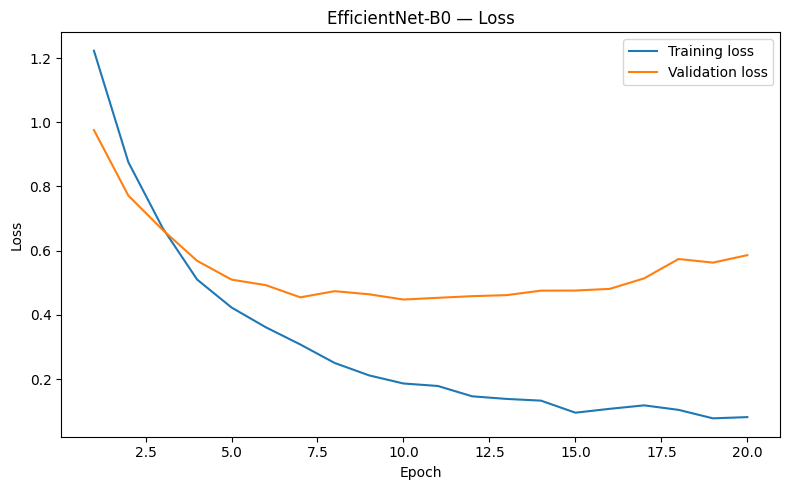

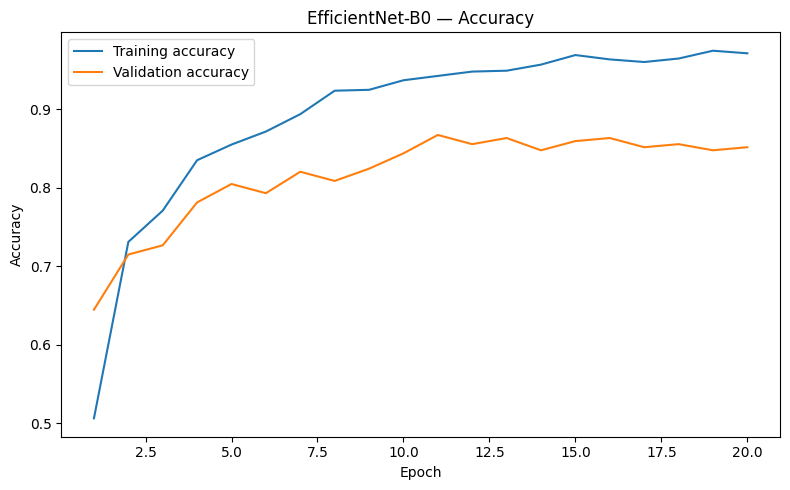

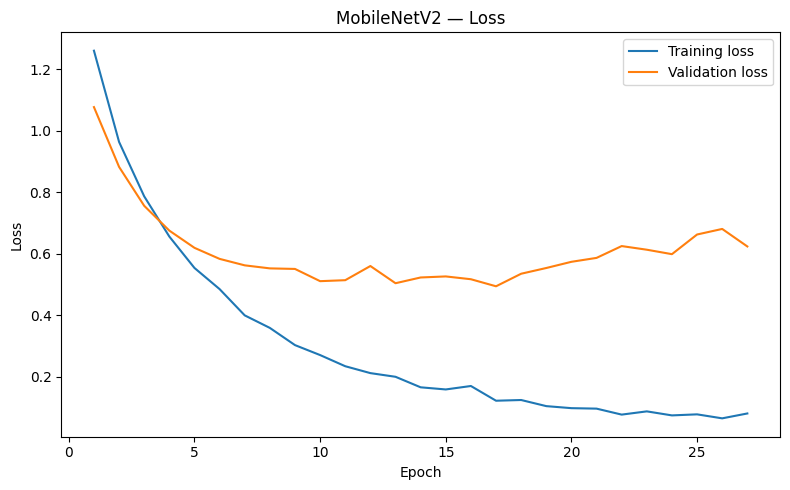

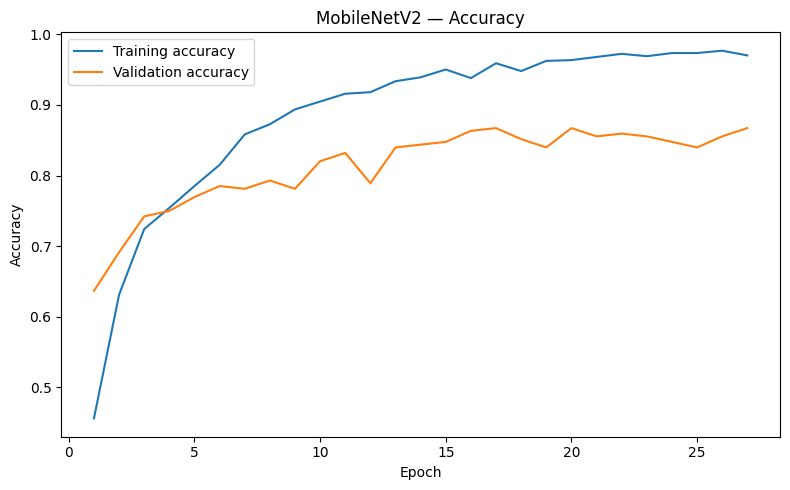

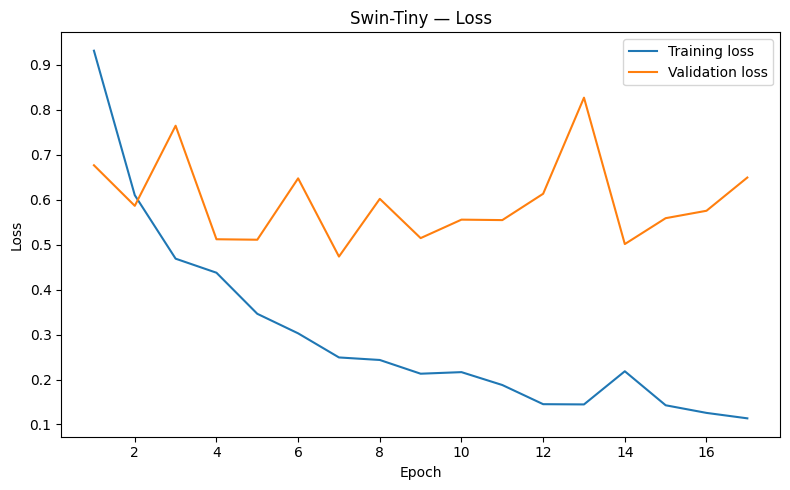

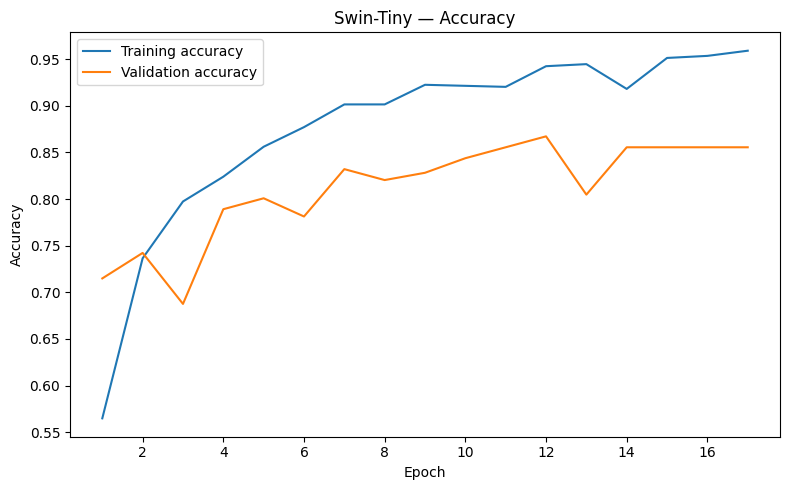

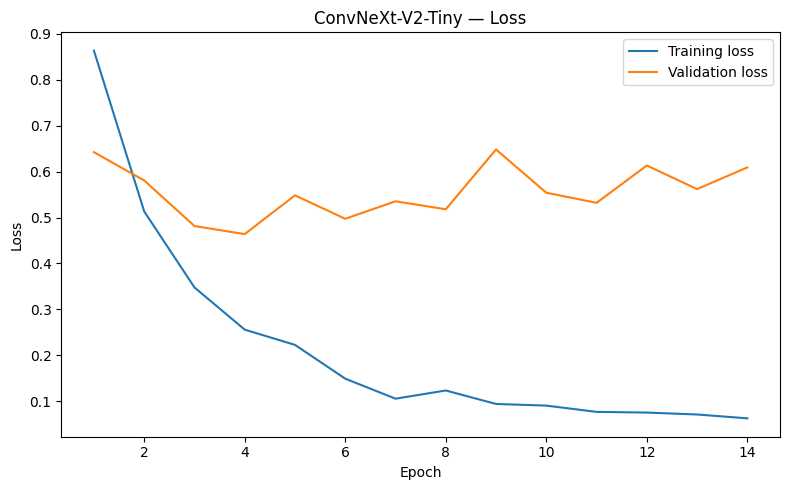

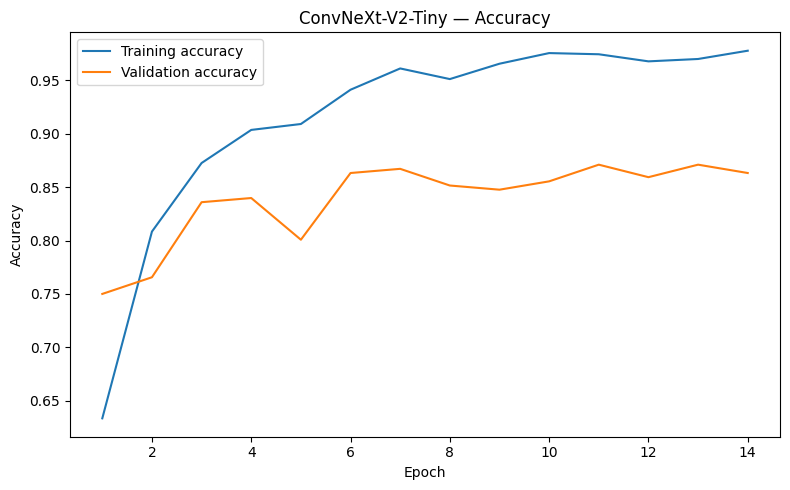

In [46]:
# ============================================================
# TRAINING CURVES
# ============================================================

for model_name in models_to_train:

    history = training_histories[
        model_name
    ]

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    # Loss
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training loss"
    )

    plt.plot(
        epochs,
        history["valid_loss"],
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{model_name} — Loss"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


    # Accuracy
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        history["train_acc"],
        label="Training accuracy"
    )

    plt.plot(
        epochs,
        history["valid_acc"],
        label="Validation accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"{model_name} — Accuracy"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

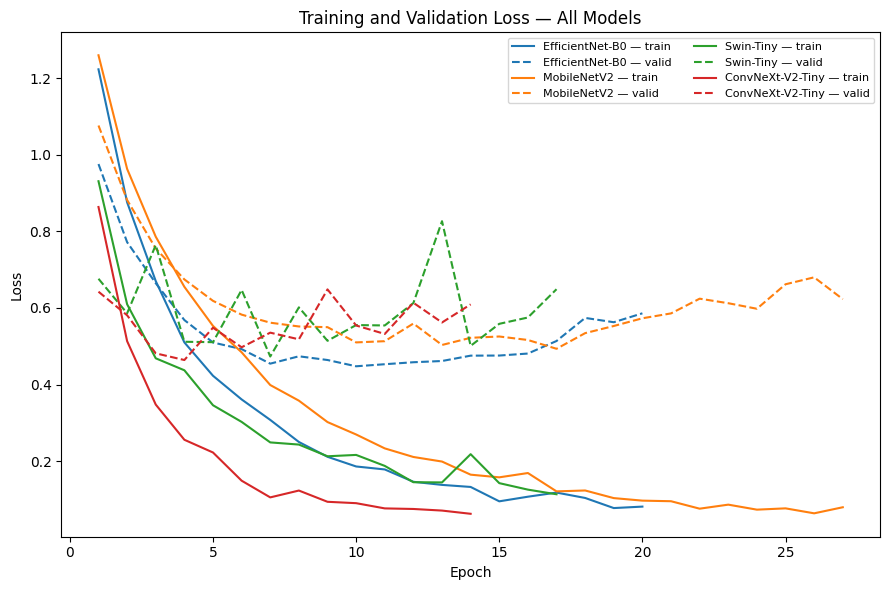

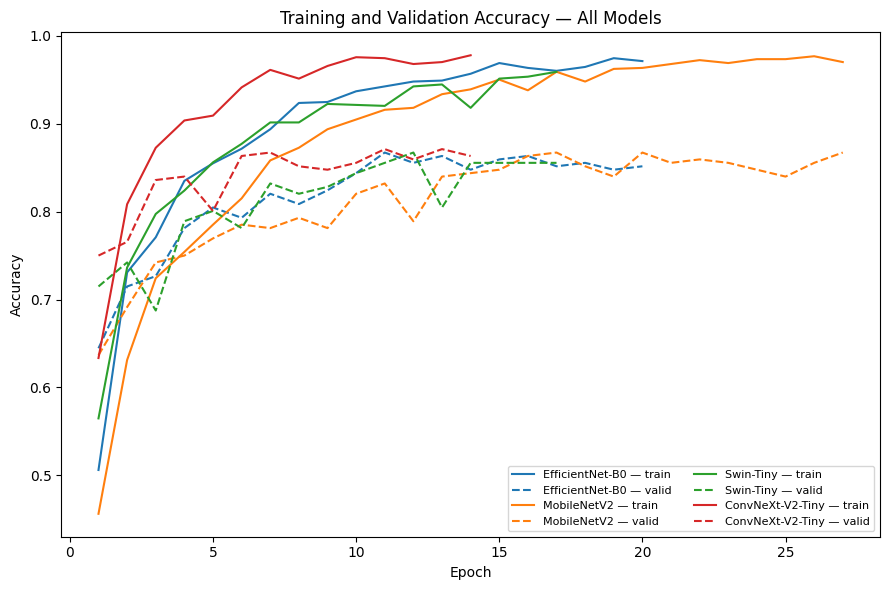

In [73]:
# ============================================================
# TRAINING CURVES — all 4 models overlaid, 2 figures total
# ============================================================

colors = plt.cm.tab10.colors  # distinct color per model

# ---- Figure 1: Loss (train + valid, all models) ----
plt.figure(figsize=(9, 6))
for i, model_name in enumerate(models_to_train):
    history = training_histories[model_name]
    epochs = range(1, len(history["train_loss"]) + 1)
    color = colors[i % len(colors)]

    plt.plot(epochs, history["train_loss"], label=f"{model_name} — train", color=color, linestyle="-")
    plt.plot(epochs, history["valid_loss"], label=f"{model_name} — valid", color=color, linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss — All Models")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "training_curves_loss_all_models.png"), dpi=150, bbox_inches="tight")
plt.show()

# ---- Figure 2: Accuracy (train + valid, all models) ----
plt.figure(figsize=(9, 6))
for i, model_name in enumerate(models_to_train):
    history = training_histories[model_name]
    epochs = range(1, len(history["train_acc"]) + 1)
    color = colors[i % len(colors)]

    plt.plot(epochs, history["train_acc"], label=f"{model_name} — train", color=color, linestyle="-")
    plt.plot(epochs, history["valid_acc"], label=f"{model_name} — valid", color=color, linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy — All Models")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "training_curves_accuracy_all_models.png"), dpi=150, bbox_inches="tight")
plt.show()

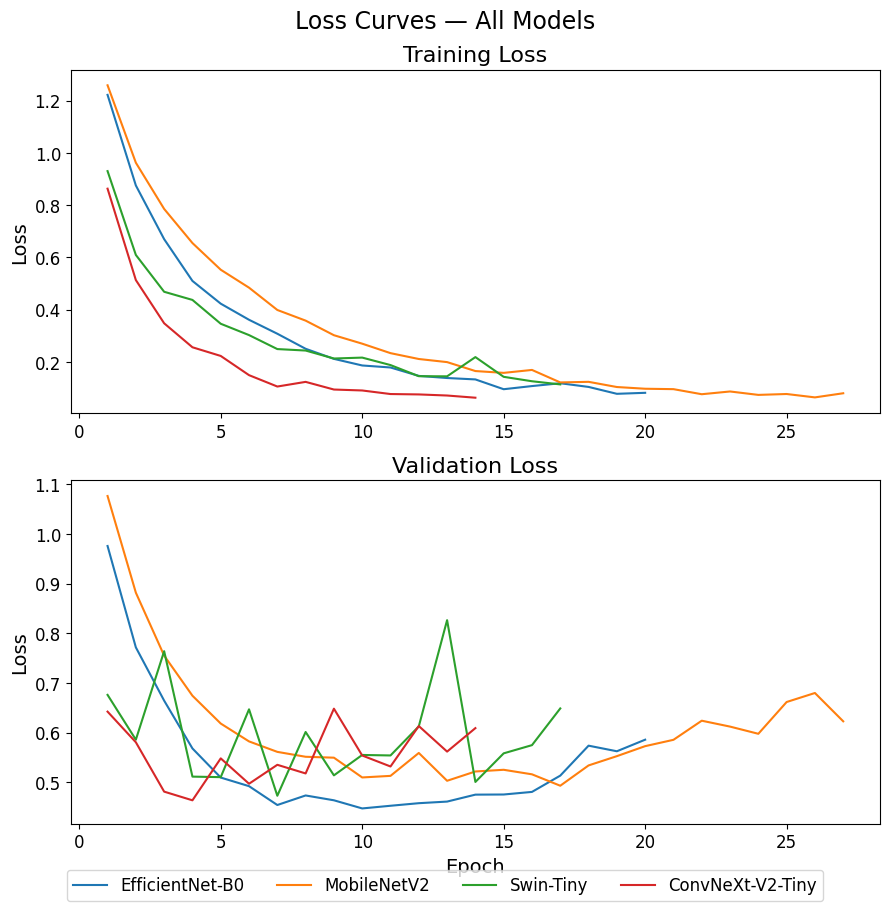

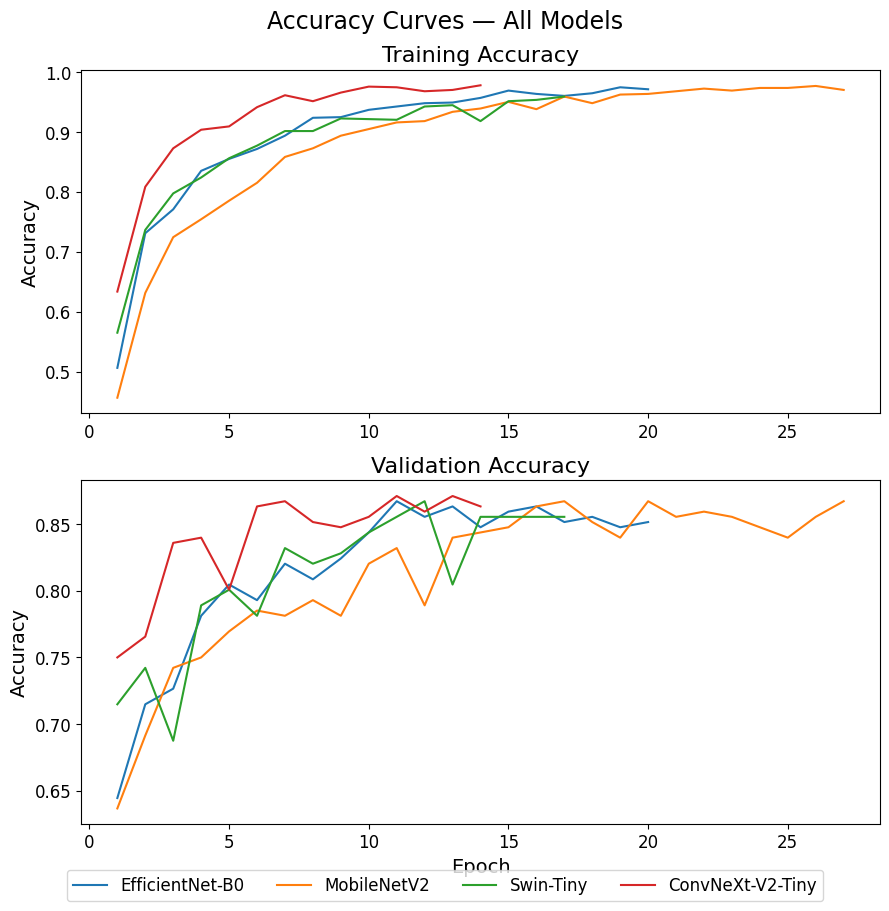

In [76]:
# ============================================================
# TRAINING CURVES — Train on top, Valid on bottom
# ============================================================

colors = plt.cm.tab10.colors

# ---- Font sizes ----
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 12
SUPTITLE_SIZE = 17


# ============================================================
# Figure 1: Loss
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=False)

for i, model_name in enumerate(models_to_train):
    history = training_histories[model_name]
    epochs = range(1, len(history["train_loss"]) + 1)
    color = colors[i % len(colors)]

    axes[0].plot(
        epochs,
        history["train_loss"],
        label=model_name,
        color=color
    )

    axes[1].plot(
        epochs,
        history["valid_loss"],
        label=model_name,
        color=color
    )

# Titles
axes[0].set_title("Training Loss", fontsize=TITLE_SIZE)
axes[1].set_title("Validation Loss", fontsize=TITLE_SIZE)

# Axis labels
axes[0].set_ylabel("Loss", fontsize=LABEL_SIZE)
axes[1].set_ylabel("Loss", fontsize=LABEL_SIZE)
axes[1].set_xlabel("Epoch", fontsize=LABEL_SIZE)

# Tick labels
axes[0].tick_params(axis="both", labelsize=TICK_SIZE)
axes[1].tick_params(axis="both", labelsize=TICK_SIZE)

# Legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=LEGEND_SIZE
)

# Main title
fig.suptitle(
    "Loss Curves — All Models",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "training_curves_loss_all_models.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Figure 2: Accuracy
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=False)

for i, model_name in enumerate(models_to_train):
    history = training_histories[model_name]
    epochs = range(1, len(history["train_acc"]) + 1)
    color = colors[i % len(colors)]

    axes[0].plot(
        epochs,
        history["train_acc"],
        label=model_name,
        color=color
    )

    axes[1].plot(
        epochs,
        history["valid_acc"],
        label=model_name,
        color=color
    )

# Titles
axes[0].set_title("Training Accuracy", fontsize=TITLE_SIZE)
axes[1].set_title("Validation Accuracy", fontsize=TITLE_SIZE)

# Axis labels
axes[0].set_ylabel("Accuracy", fontsize=LABEL_SIZE)
axes[1].set_ylabel("Accuracy", fontsize=LABEL_SIZE)
axes[1].set_xlabel("Epoch", fontsize=LABEL_SIZE)

# Tick labels
axes[0].tick_params(axis="both", labelsize=TICK_SIZE)
axes[1].tick_params(axis="both", labelsize=TICK_SIZE)

# Legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=LEGEND_SIZE
)

# Main title
fig.suptitle(
    "Accuracy Curves — All Models",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_DIR,
        "training_curves_accuracy_all_models.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [47]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

def evaluate_test_set(
    model,
    model_name
):

    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    start_time = time.time()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = (
                outputs.argmax(dim=1)
                .cpu()
                .numpy()
            )

            all_true.extend(
                labels.numpy()
            )

            all_pred.extend(
                predictions
            )

            all_prob.append(
                probabilities
                .cpu()
                .numpy()
            )

    inference_time = (
        time.time() - start_time
    )

    y_true = np.array(
        all_true
    )

    y_pred = np.array(
        all_pred
    )

    y_prob = np.vstack(
        all_prob
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        f"Accuracy    : {accuracy:.4f}"
    )

    print(
        f"Macro Precision : {precision:.4f}"
    )

    print(
        f"Macro Recall    : {recall:.4f}"
    )

    print(
        f"Macro F1       : {macro_f1:.4f}"
    )

    print(
        f"Weighted F1    : {weighted_f1:.4f}"
    )

    print("\nClassification report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            labels=range(NUM_CLASSES),
            target_names=CLASS_ORDER,
            digits=4,
            zero_division=0
        )
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "inference_time": inference_time
    }

In [48]:
# ============================================================
# EVALUATE ALL MODELS
# ============================================================

image_results = {}

for model_name in models_to_train:

    image_results[model_name] = evaluate_test_set(
        trained_models[model_name],
        model_name
    )


EfficientNet-B0
Accuracy    : 0.7895
Macro Precision : 0.7967
Macro Recall    : 0.8228
Macro F1       : 0.8027
Weighted F1    : 0.7958

Classification report:

              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000         9
        Mild     0.9070    0.7647    0.8298        51
    Moderate     0.5000    0.7333    0.5946        15
      Severe     0.7797    0.7931    0.7863        58

    accuracy                         0.7895       133
   macro avg     0.7967    0.8228    0.8027       133
weighted avg     0.8119    0.7895    0.7958       133


MobileNetV2
Accuracy    : 0.7895
Macro Precision : 0.7819
Macro Recall    : 0.7863
Macro F1       : 0.7817
Weighted F1    : 0.7941

Classification report:

              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000         9
        Mild     0.9091    0.7843    0.8421        51
    Moderate     0.4444    0.5333    0.4848        15
      Severe     0.7742    0.8

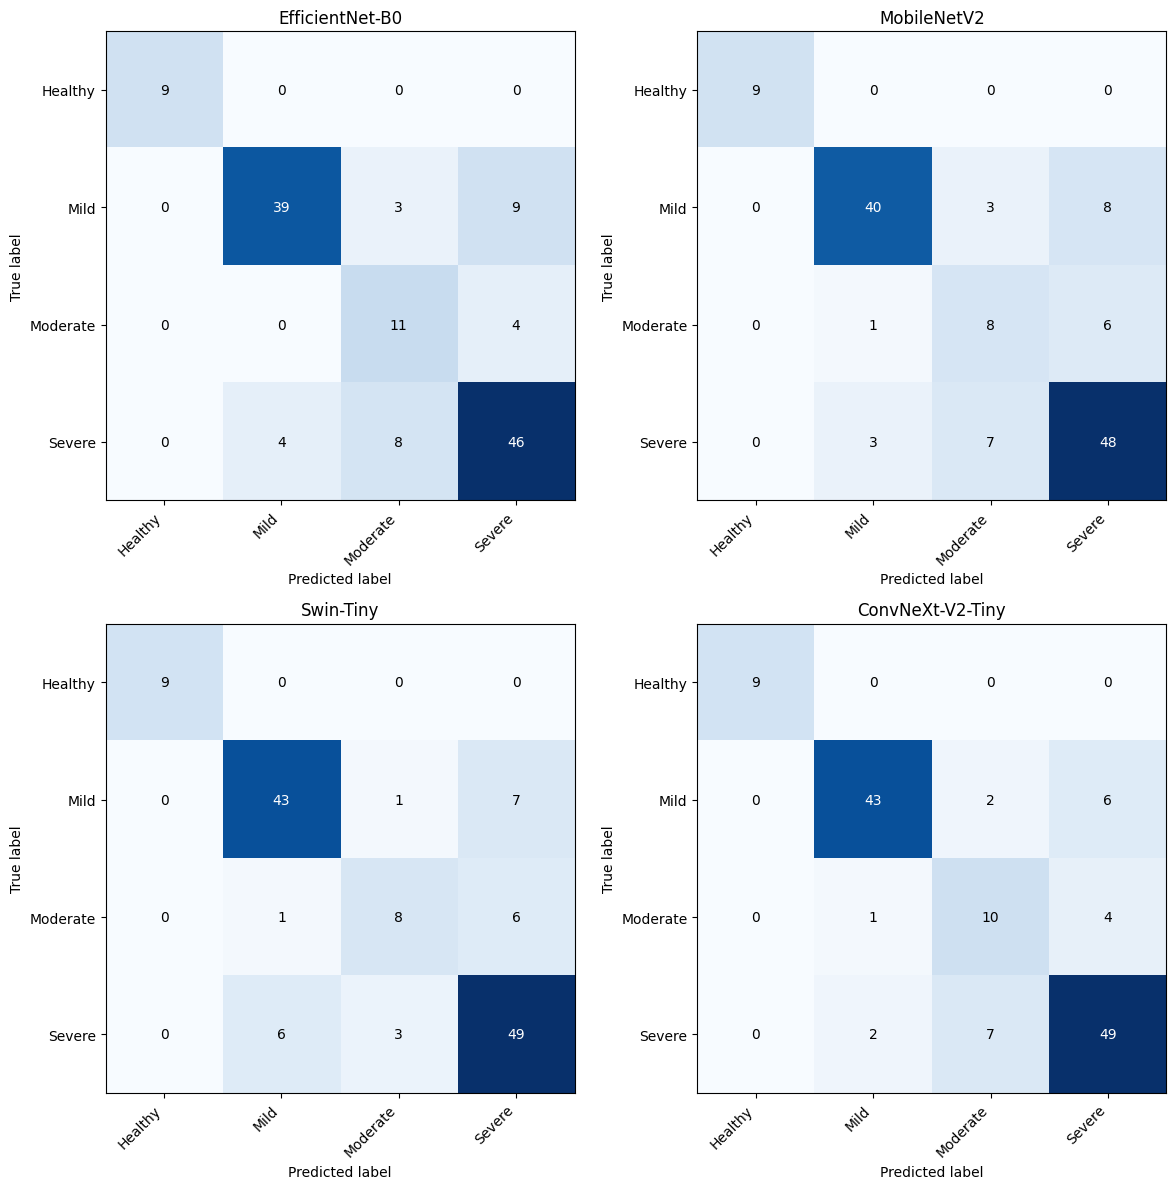

In [49]:
# ============================================================
# CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)
axes = axes.flatten()  # <-- flatten 2x2 array into a list of 4 axes

for ax, model_name in zip(
    axes,
    models_to_train
):
    result = image_results[
        model_name
    ]
    cm = confusion_matrix(
        result["y_true"],
        result["y_pred"],
        labels=range(NUM_CLASSES)
    )
    im = ax.imshow(
        cm,
        interpolation="nearest",
        cmap="Blues"
    )
    ax.set_title(
        model_name
    )
    ax.set_xticks(
        range(NUM_CLASSES)
    )
    ax.set_yticks(
        range(NUM_CLASSES)
    )
    ax.set_xticklabels(
        CLASS_ORDER,
        rotation=45,
        ha="right"
    )
    ax.set_yticklabels(
        CLASS_ORDER
    )
    ax.set_xlabel(
        "Predicted label"
    )
    ax.set_ylabel(
        "True label"
    )
    # Write values into cells
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > cm.max() / 2
                    else "black"
                )
            )
plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# IMAGE CLASSIFICATION COMPARISON
# ============================================================

image_comparison = pd.DataFrame([
    {
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Macro Precision": result["macro_precision"],
        "Macro Recall": result["macro_recall"],
        "Macro F1": result["macro_f1"],
        "Weighted F1": result["weighted_f1"],
        "Training Time (s)": training_times[model_name],
        "Test Inference Time (s)": result["inference_time"]
    }

    for model_name, result
    in image_results.items()
])

image_comparison = image_comparison.sort_values(
    "Macro F1",
    ascending=False
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)

image_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Test Inference Time (s)
3,ConvNeXt-V2-Tiny,0.8346,0.8229,0.8387,0.8281,0.8393,556.7603,2.6615
2,Swin-Tiny,0.8195,0.8292,0.8053,0.8152,0.8172,882.8429,1.7227
0,EfficientNet-B0,0.7895,0.7967,0.8228,0.8027,0.7958,296.1211,1.7524
1,MobileNetV2,0.7895,0.7819,0.7863,0.7817,0.7941,388.6318,1.5776


Box annotation counts per split and symptom class:

class   mushroom  rot  white-button
source                             
train       1645  580           658
valid        483  159           208
test         144   76           101

Total boxes per class (all splits):
class
mushroom        2272
rot              815
white-button     967
dtype: int64

Total boxes per split (all classes):
source
train    2883
valid     850
test      321
dtype: int64


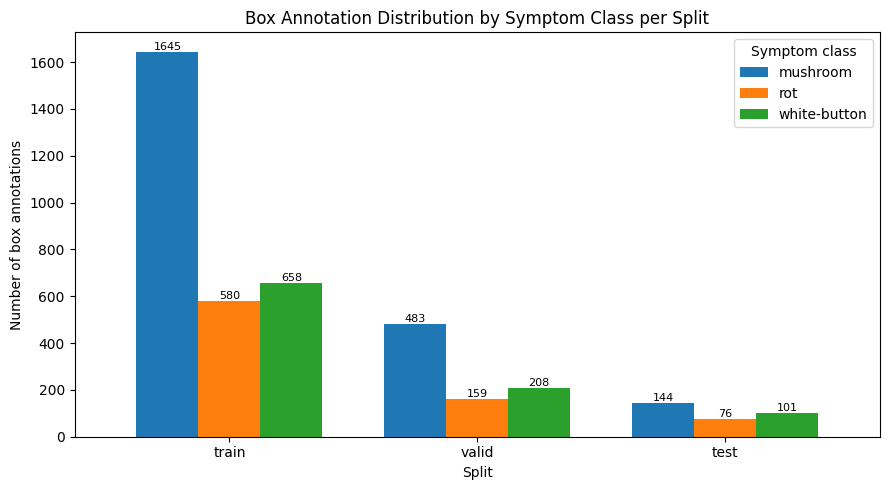

In [52]:
# ============================================================
# BOX ANNOTATION DISTRIBUTION BY SYMPTOM CLASS (per split)
# ============================================================
from collections import Counter

box_counts = Counter()  # (split, class_name) -> count

for rec in records:

    label_path = rec["label_path"]
    split = rec["source"]

    if not label_path.exists():
        continue

    with open(label_path, "r") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) < 5:
                continue

            cls_id = int(float(parts[0]))

            if cls_id < 0 or cls_id >= len(class_names):
                continue

            cls_name = class_names[cls_id]

            box_counts[(split, cls_name)] += 1

# Tidy long-format DataFrame: one row per (split, class) combo
box_df = pd.DataFrame(
    [
        {"source": split, "class": cls_name, "count": count}
        for (split, cls_name), count in box_counts.items()
    ]
)

# Pivot to split x class table (rows = split, cols = symptom class)
box_pivot = (
    box_df.pivot_table(
        index="source",
        columns="class",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(SPLITS_TO_PROCESS)   # consistent split order: train, valid, test
    .reindex(columns=class_names)  # consistent class order
    .fillna(0)
    .astype(int)
)

print("Box annotation counts per split and symptom class:\n")
print(box_pivot)

print("\nTotal boxes per class (all splits):")
print(box_pivot.sum(axis=0))

print("\nTotal boxes per split (all classes):")
print(box_pivot.sum(axis=1))

# Grouped bar chart
ax = box_pivot.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.75
)

ax.set_title("Box Annotation Distribution by Symptom Class per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of box annotations")
ax.legend(title="Symptom class")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()

# Additional workpiece for report

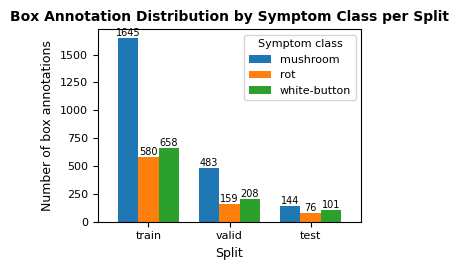

In [48]:
# Grouped bar chart
# Sized for a double-column A4 figure (~3.5in column width)
ax = box_pivot.plot(
    kind="bar",
    figsize=(3.5, 2.8),
    width=0.75
)

ax.set_title("Box Annotation Distribution by Symptom Class per Split", fontsize=10, fontweight="bold")
ax.set_xlabel("Split", fontsize=9)
ax.set_ylabel("Number of box annotations", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.legend(title="Symptom class", fontsize=8, title_fontsize=8)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fontsize=7)

plt.tight_layout()
plt.savefig("box_annotation_distribution_by_split.png", dpi=300, bbox_inches="tight")
plt.show()

Image counts per split:

train    903
valid    256
test     133
Name: count, dtype: int64

Total images: 1,292


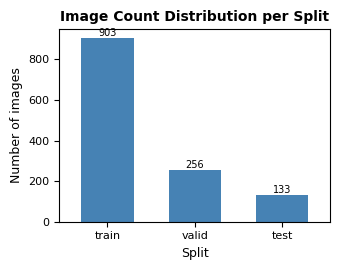

In [49]:
# ============================================================
# IMAGE COUNT DISTRIBUTION PER SPLIT
# ============================================================
image_counts = (
    pd.Series([rec["source"] for rec in records])
    .value_counts()
    .reindex(SPLITS_TO_PROCESS)
    .fillna(0)
    .astype(int)
)

print("Image counts per split:\n")
print(image_counts)
print(f"\nTotal images: {image_counts.sum():,}")

# Bar chart — sized for a double-column A4 figure (~3.5in column width)
fig, ax = plt.subplots(figsize=(3.5, 2.8))

image_counts.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    width=0.6
)

ax.set_title("Image Count Distribution per Split", fontsize=10, fontweight="bold")
ax.set_xlabel("Split", fontsize=9)
ax.set_ylabel("Number of images", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fontsize=7)

plt.tight_layout()
plt.savefig("image_count_distribution_by_split.png", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
import numpy as np
from PIL import Image, ImageDraw

def draw_annotations(img_path, label_path, only_class_id=None):
    """Draw YOLO-format boxes from a label .txt file onto the image (optionally filtered to one class)."""
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size

    label_path = Path(label_path)
    if label_path.is_file():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                if only_class_id is not None and cls_id != only_class_id:
                    continue
                x1, y1 = (xc - bw / 2) * w, (yc - bh / 2) * h
                x2, y2 = (xc + bw / 2) * w, (yc + bh / 2) * h
                draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
                draw.text((x1, max(y1 - 12, 0)), class_names[cls_id], fill="red")

    return np.array(img)

Found 4 Severe->Healthy failures (Random Forest pipeline)
                                                 image  box_count  \
7    test/IMG_0041_JPG.rf.633e004ba6aceaa52817ef83e...          0   
8    test/IMG_0041_JPG.rf.cd7cf115e6d39ceb87ed63d6f...          0   
11   test/IMG_0067_JPG.rf.22baf0f479021b1f0a6388211...          0   
112  test/IMG_9832_JPG.rf.d37fa226f9a1783e2a0c90773...          0   

     rot_area_ratio  fruiting_body_count  
7            0.0000                    0  
8            0.0000                    0  
11           0.0000                    0  
112          0.0000                    0  


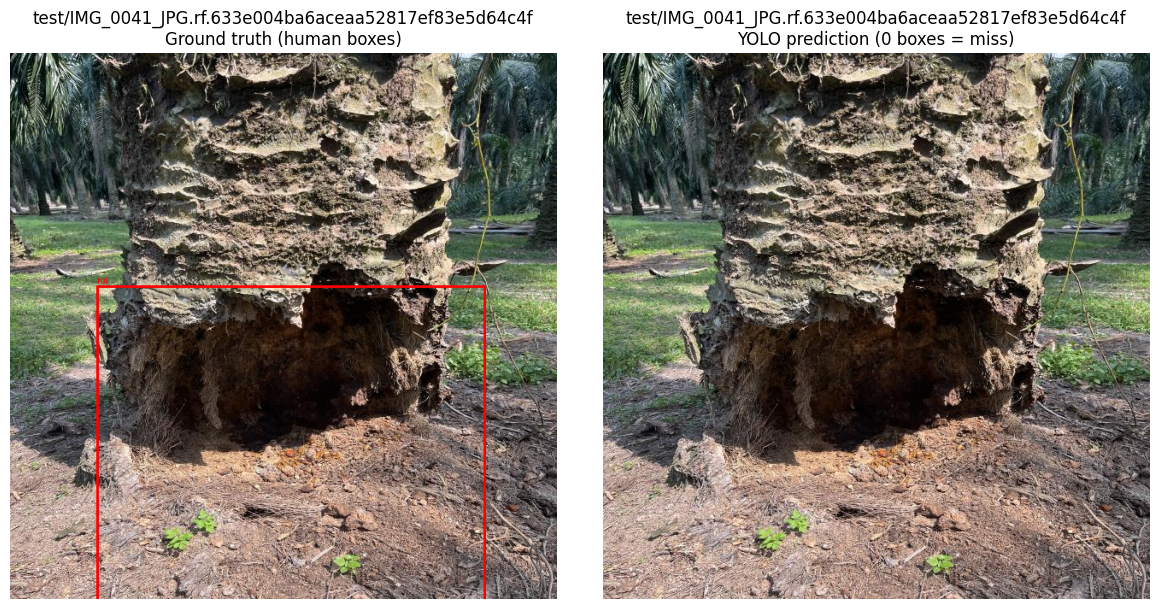

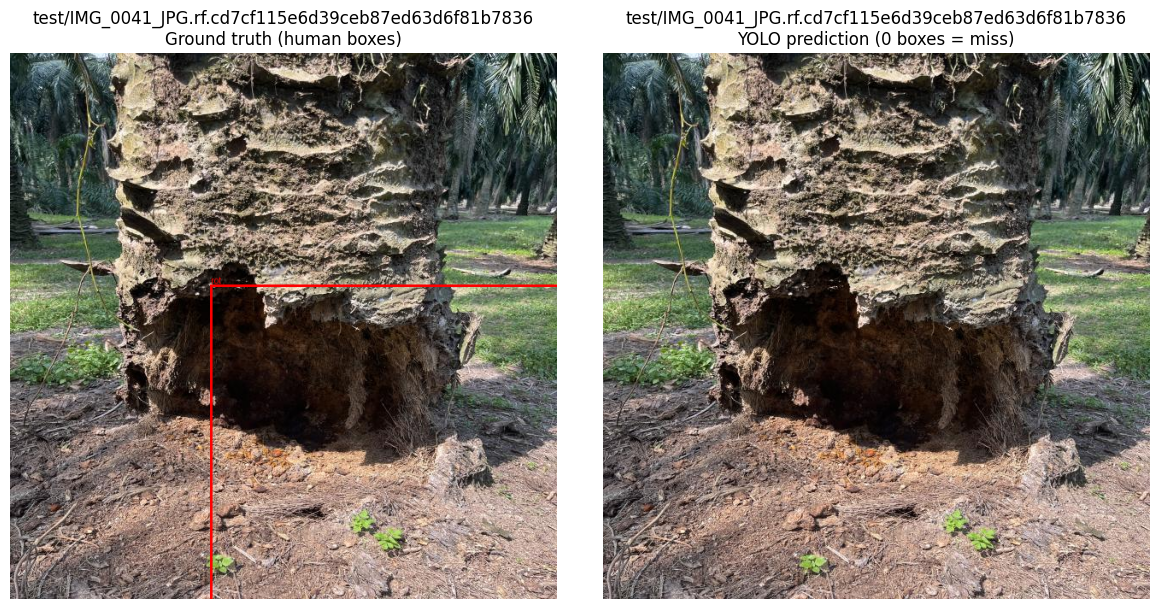

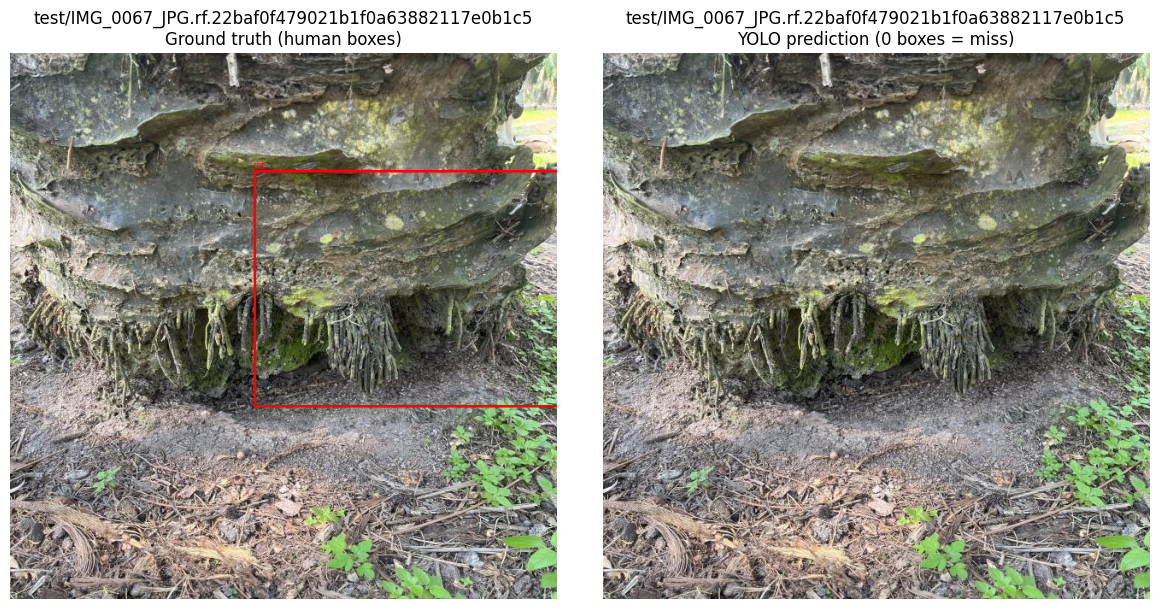

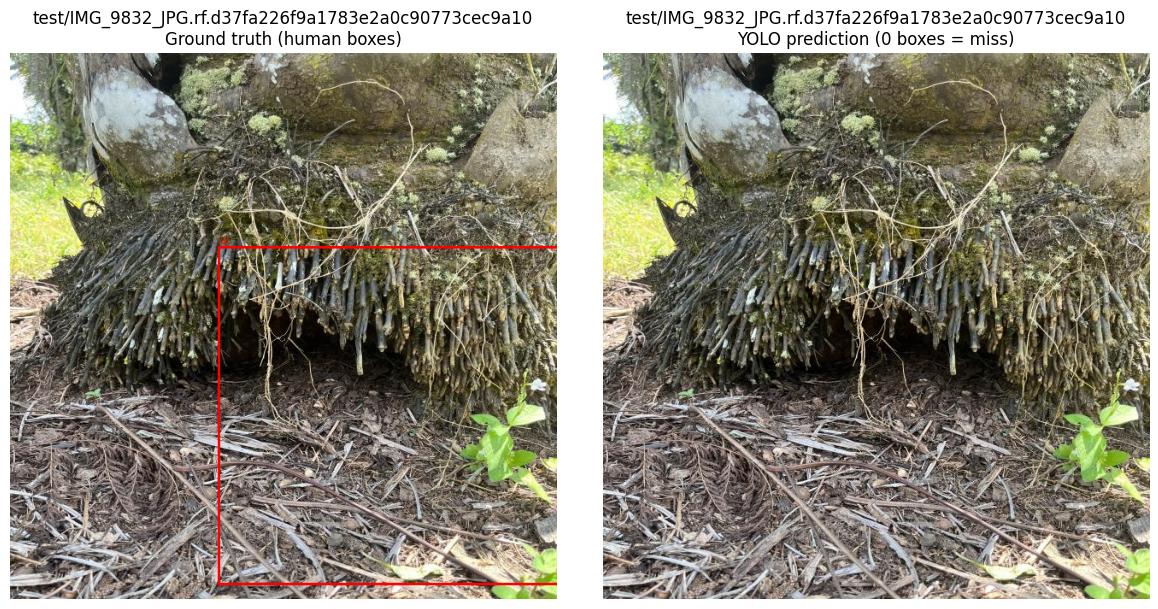

In [55]:
# So yes: this is very likely YOLO missing detections entirely on those 5 images 
# — true false negatives — not a feature-scoring or classifier problem. The RF/KNN can't invent evidence YOLO never gave it.
import matplotlib.pyplot as plt

# Find images where ground truth = Severe but the pipeline predicted Healthy
severe_idx = CLASS_ORDER.index("Severe")
healthy_idx = CLASS_ORDER.index("Healthy")

# use whichever prediction array you're inspecting (KNN or RF pipeline)
failure_mask = (y_true_pipeline == severe_idx) & (y_pred_rf_pipeline == healthy_idx)
failure_images = pred_df.loc[failure_mask, "image"].tolist()

print(f"Found {len(failure_images)} Severe->Healthy failures (Random Forest pipeline)")
print(pred_df.loc[failure_mask, ["image", "box_count", "rot_area_ratio", "fruiting_body_count"]])

# Visualize each: ground-truth boxes vs YOLO's (empty) predicted boxes, side by side
for image_stem in failure_images:
    rec = next(r for r in test_records if r["image"] == image_stem)
    img_path = find_image_for_label(rec["label_path"], IMAGE_EXTS)

    gt_annotated = draw_annotations(img_path, rec["label_path"], only_class_id=None)

    result = yolo_model.predict(str(img_path), imgsz=YOLO_IMGSZ, conf=YOLO_CONF_THRESHOLD, verbose=False)[0]
    yolo_img = plt.imread(img_path)  # raw image; result.plot() also works and draws YOLO's own boxes
    yolo_annotated = result.plot()   # returns numpy array with YOLO's predicted boxes drawn (BGR->may need [:,:,::-1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(gt_annotated)
    axes[0].set_title(f"{image_stem}\nGround truth (human boxes)")
    axes[0].axis("off")

    axes[1].imshow(yolo_annotated[:, :, ::-1])  # BGR -> RGB
    axes[1].set_title(f"{image_stem}\nYOLO prediction (0 boxes = miss)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()